In [1]:
#!pip install imblearn --break-system-packages
#!pip install lightgbm --break-system-packages
#!pip install category_encoders --break-system-packages
#!pip install optuna --break-system-packages
#!pip install scikit-plot --break-system-packages
#%pip install scipy==1.11.4 --break-system-packages
import numpy as np
import pandas as pd

# libraries to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, label_binarize,TargetEncoder,StandardScaler
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, validation_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import f1_score,classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import RocCurveDisplay,PrecisionRecallDisplay
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from imblearn.over_sampling import SMOTE

from scipy.stats import randint

import optuna
from optuna.importance import FanovaImportanceEvaluator
from optuna.importance import MeanDecreaseImpurityImportanceEvaluator

from xgboost import XGBClassifier
import xgboost as xgb

from lightgbm import LGBMClassifier

from itertools import product

from sklearn.inspection import DecisionBoundaryDisplay


/home/diptyajitdas/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# read the file into a pandas dataframe
df = pd.read_csv('driver.csv').drop(columns=['Unnamed: 0'])
# look at the datatypes of the columns
print('*************************************************')
print(df.info())
print('*************************************************\n')
print('*************************************************')
print(f'Shape of the dataset is {df.shape}')
print('*************************************************\n')
print('*************************************************')
print(f'Number of nan/null values in each column: \n{df.isna().sum()}')
print('*************************************************\n')
print('*************************************************')
print(f'Number of unique values in each column: \n{df.nunique()}')
print('*************************************************\n')
print('*************************************************')
print(f'Duplicate entries: \n{df.duplicated().value_counts()}')

*************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MMM-YY                19104 non-null  object 
 1   Driver_ID             19104 non-null  int64  
 2   Age                   19043 non-null  float64
 3   Gender                19052 non-null  float64
 4   City                  19104 non-null  object 
 5   Education_Level       19104 non-null  int64  
 6   Income                19104 non-null  int64  
 7   Dateofjoining         19104 non-null  object 
 8   LastWorkingDate       1616 non-null   object 
 9   Joining Designation   19104 non-null  int64  
 10  Grade                 19104 non-null  int64  
 11  Total Business Value  19104 non-null  int64  
 12  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 1.9+ MB
None
*********

In [3]:
df.head(5)

,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [4]:
df.describe()

,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19043.000000,19052.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,1415.591133,34.668435,0.418749,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899
std,810.705321,6.257912,0.493367,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832
min,1.000000,21.000000,0.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000
25%,710.000000,30.000000,0.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000
50%,1417.000000,34.000000,0.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000
75%,2137.000000,39.000000,1.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000
max,2788.000000,58.000000,1.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000


In [5]:
df.describe(include='object')

,MMM-YY,City,Dateofjoining,LastWorkingDate
count,19104,19104,19104,1616
unique,24,29,869,493
top,01/01/19,C20,23/07/15,29/07/20
freq,1022,1008,192,70


### Insight
- There are **19104** entries with 14 columns
- There are **61 null/missing values in *Age*, 52 in *Gender* and 17488 in *LastWorkingDate***
- There are **2381 unique drivers**
- There are no **duplicates**
- The column ***Unnamed: 0*** can be dropped as it doesnt provide any new information
- The columns ***Gender, City, Education_Level, Joining Designation, Grade*** and  ***Quarterly Rating*** can be converted to **categorical** datatype
- The columns ***MMM-YY, Dateofjoining*** and ***LastWorkingDate*** can be converted to **datetime** datatype
- Drivers who donot have valid ***LastWorkingDate*** can be considered as **churned**

In [6]:
# Convert to category
categorical_columns = ['Gender', 'City', 'Education_Level', 'Joining Designation', 'Grade']
df[categorical_columns] = df[categorical_columns].astype('category')
df['Gender'].replace({0.0:'Male', 1.0: 'Female'}, inplace=True)
df['Education_Level'].replace({0:'10+', 1:'12+', 2:'Graduate'}, inplace=True)

# Convert to datetime
df['MMM-YY'] = pd.to_datetime(df['MMM-YY'], format='%m/%d/%y')
df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'], format='%d/%m/%y')
df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'], format='%d/%m/%y')

# Rename 'MMM-YY' to 'ReportingMonthYear'
df.rename(columns={'MMM-YY':'ReportingMonthYear'}, inplace=True)
df['ReportingMonthYear'] = df['ReportingMonthYear'].dt.to_period('M')
df['ReportingYear'] = df['ReportingMonthYear'].dt.year

# Extract month and year from 'Dateofjoining'
df['Monthofjoining'] = df['Dateofjoining'].dt.month
df['Yearofjoining'] = df['Dateofjoining'].dt.year

# Find drivers who haved churned
df['Churn'] = df.groupby('Driver_ID')['LastWorkingDate'].transform('last')
df['Churn'] = df['Churn'].apply(lambda x: 0 if pd.isnull(x) else 1)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ReportingMonthYear    19104 non-null  period[M]     
 1   Driver_ID             19104 non-null  int64         
 2   Age                   19043 non-null  float64       
 3   Gender                19052 non-null  category      
 4   City                  19104 non-null  category      
 5   Education_Level       19104 non-null  category      
 6   Income                19104 non-null  int64         
 7   Dateofjoining         19104 non-null  datetime64[ns]
 8   LastWorkingDate       1616 non-null   datetime64[ns]
 9   Joining Designation   19104 non-null  category      
 10  Grade                 19104 non-null  category      
 11  Total Business Value  19104 non-null  int64         
 12  Quarterly Rating      19104 non-null  int64         
 13  ReportingYear   

/tmp/ipykernel_16057/2093539267.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace({0.0:'Male', 1.0: 'Female'}, inplace=True)
/tmp/ipykernel_16057/2093539267.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Gender'].replace({0.0:'Male', 1.0: 'Female'}, inplace=True)
/tmp/ipykernel_16057/

In [7]:
df.head()

,ReportingMonthYear,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,ReportingYear,Monthofjoining,Yearofjoining,Churn
0,2019-01,1,28.0,Male,C23,Graduate,57387,2018-12-24,NaT,1,1,2381060,2,2019,12,2018,1
1,2019-02,1,28.0,Male,C23,Graduate,57387,2018-12-24,NaT,1,1,-665480,2,2019,12,2018,1
2,2019-03,1,28.0,Male,C23,Graduate,57387,2018-12-24,2019-11-03,1,1,0,2,2019,12,2018,1
3,2020-11,2,31.0,Male,C7,Graduate,67016,2020-06-11,NaT,2,2,0,1,2020,6,2020,0
4,2020-12,2,31.0,Male,C7,Graduate,67016,2020-06-11,NaT,2,2,0,1,2020,6,2020,0


# Exploratory Data Analysis

## Univariate analysis

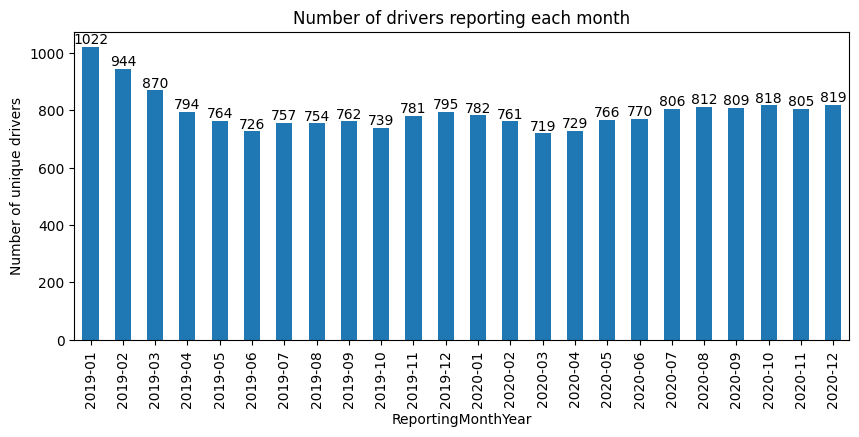

In [8]:
plt.figure(figsize=(10,4))
temp_df = df.groupby('ReportingMonthYear')['Driver_ID'].nunique()
ax = temp_df.plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.ylabel('Number of unique drivers')
plt.title('Number of drivers reporting each month')
plt.show()

### Insight
- The **month** during which **maximum** number of **drivers reported is January 2019**. A total of **1022 drivers** reported on January 2019
- It then dropeed every month after January and has been stagnant at around 800 drivers reported every month

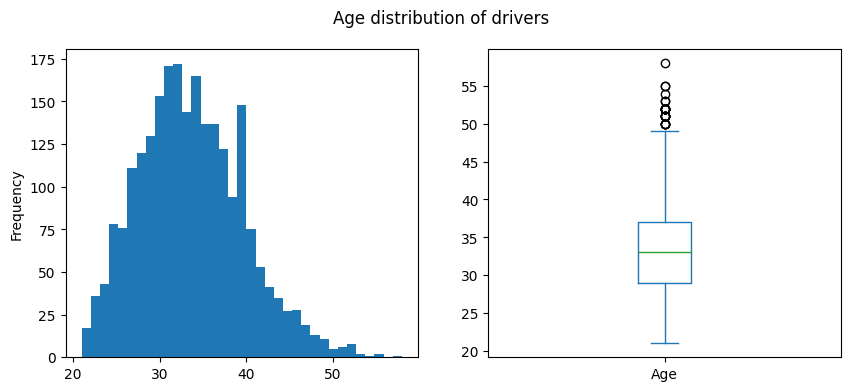

In [9]:
fig, axs = plt.subplots(1,2,figsize=(10,4))
temp_df = df.groupby('Driver_ID').agg({'Age':'last'})['Age']
temp_df.plot(ax=axs[0], kind='hist', bins=35)
temp_df.plot(ax=axs[1], kind='box')
fig.suptitle('Age distribution of drivers')
plt.show()

### Insight
- There are drivers from different **age** groups ranging from **21 to 58 years**
- **Most** of the drivers are in the age group of **30 to 35**
- The distribution is mostly **normal** with **little skewness** towards the **right**

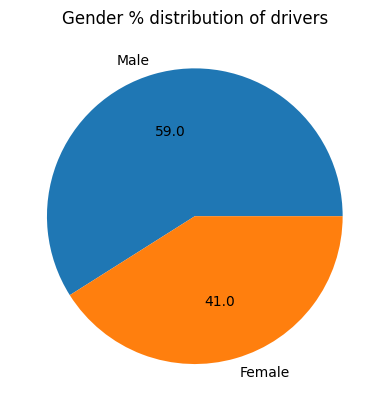

In [10]:
temp_df = df.groupby('Driver_ID').agg({'Gender':'first'})
temp_df['Gender'].value_counts().plot(kind='pie', autopct='%.1f')
plt.title('Gender % distribution of drivers')
plt.ylabel('')
plt.show()

### Insight
- **59%** of the drivers are **Male** and remaining **41%** are **Female**

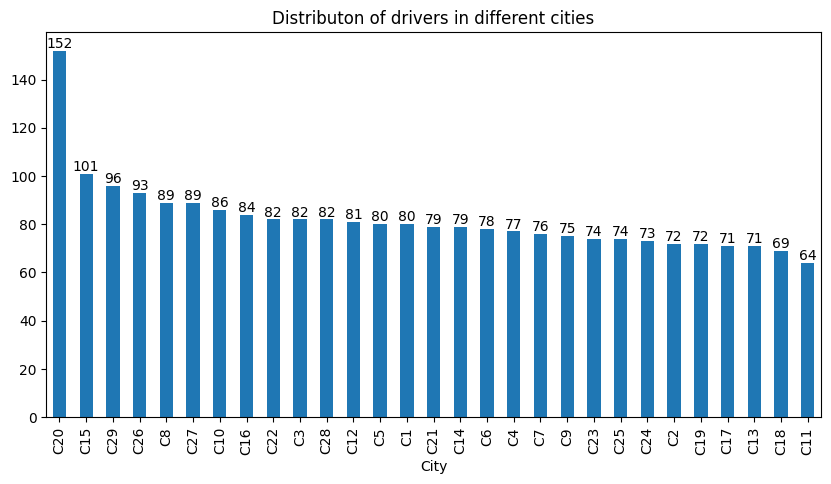

In [11]:
plt.figure(figsize=(10,5))
temp_df = df.groupby('Driver_ID').agg({'City':'first'})
ax = temp_df['City'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Distributon of drivers in different cities')
plt.show()

### Insight
- City **C20** has the **maximum** number of **drivers** followed by city C15 

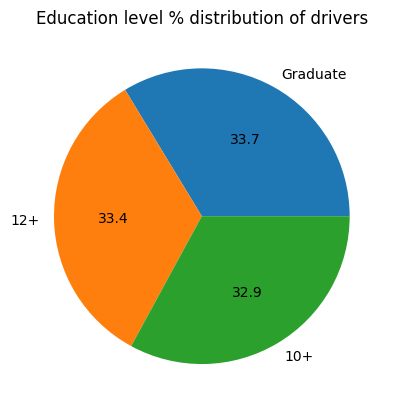

In [12]:
temp_df = df.groupby('Driver_ID').agg({'Education_Level':'first'})
temp_df['Education_Level'].value_counts().plot(kind='pie', autopct='%.1f')
plt.ylabel('')
plt.title('Education level % distribution of drivers')
plt.show()

### Insight
- Almost equal proportion of drivers are from the 3 different education level

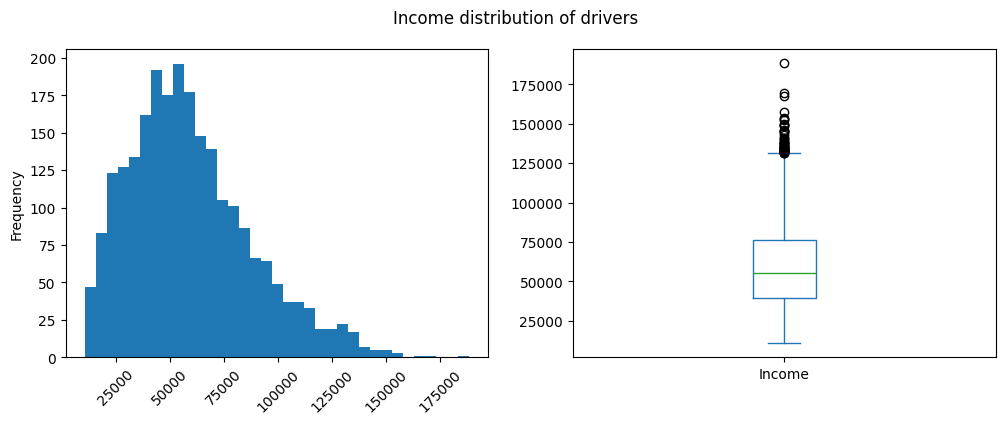

In [13]:
fig, axs = plt.subplots(1,2,figsize=(12,4))
temp_df = df.groupby('Driver_ID').agg({'Income':'last'})['Income']
temp_df.plot(ax=axs[0], kind='hist', bins=35, rot=45)
temp_df.plot(ax=axs[1], kind='box')
fig.suptitle('Income distribution of drivers')
plt.show()

### Insight
- Most of the drivers have an average monthly income of **40k to 75k**
- The distribution is **right skewed**

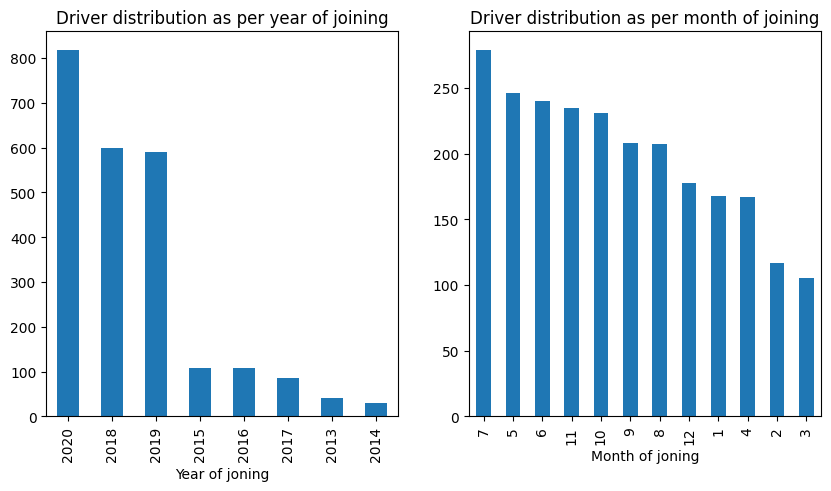

In [14]:
temp_df = df.groupby('Driver_ID').agg({'Dateofjoining':'first'})['Dateofjoining']
fig, axs = plt.subplots(1,2,figsize=(10,5))
temp_df.dt.year.value_counts().plot(kind='bar', ax=axs[0], xlabel='Year of joning', title='Driver distribution as per year of joining')
temp_df.dt.month.value_counts().plot(kind='bar', ax=axs[1], xlabel='Month of joning', title='Driver distribution as per month of joining')
plt.show()

### Insight
- Maximum number of drivers joined in the year **2020**
- Maximum number of drivers joined in the month of **July**

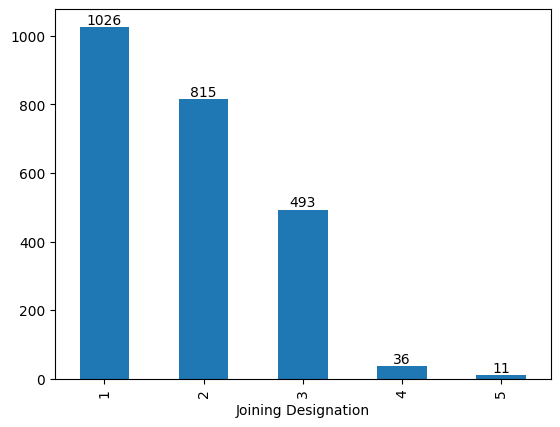

In [15]:
ax = df.groupby('Driver_ID').agg({'Joining Designation':'first'})['Joining Designation'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.show()

### Insight
- Maximum number of drivers, 1026, have a **joining designation of 1**

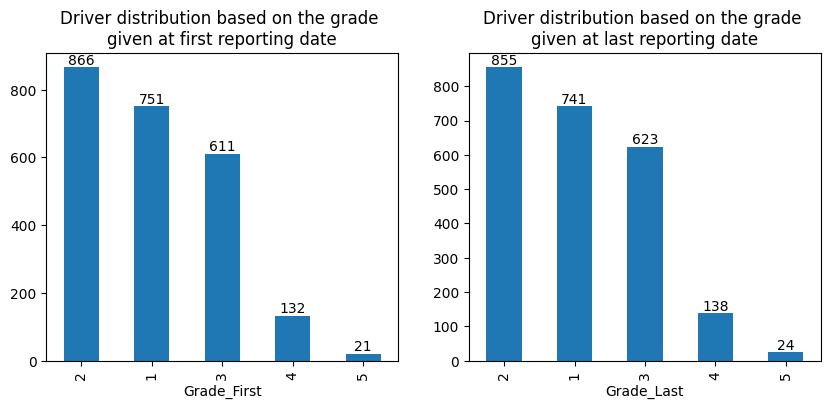

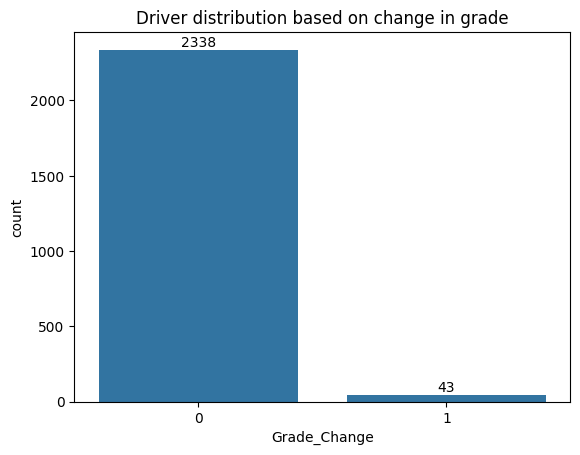

In [16]:
temp_df_1 = df.groupby('Driver_ID').agg({'Grade':'first'}).reset_index()
temp_df_1.rename(columns = {'Grade':'Grade_First'}, inplace=True)
temp_df_2 = df.groupby('Driver_ID').agg({'Grade':'last'}).reset_index()
temp_df_2.rename(columns = {'Grade':'Grade_Last'}, inplace=True)
temp_df = pd.merge(temp_df_1, temp_df_2, on='Driver_ID')
temp_df['Grade_Change'] = temp_df['Grade_Last'].astype('int') - temp_df['Grade_First'].astype('int')
fig, axs = plt.subplots(1,2,figsize=(10,4))
ax = temp_df['Grade_First'].value_counts().plot(kind='bar', ax=axs[0], title='Driver distribution based on the grade \ngiven at first reporting date')
ax.bar_label(ax.containers[0])
ax = temp_df['Grade_Last'].value_counts().plot(kind='bar', ax=axs[1], title='Driver distribution based on the grade \ngiven at last reporting date')
ax.bar_label(ax.containers[0])
plt.show()
ax = sns.countplot(data=temp_df, x = 'Grade_Change')
ax.set_title('Driver distribution based on change in grade')
ax.bar_label(ax.containers[0])
plt.show()

### Insight
- Maximum number of drivers have a **grade of 2** and it doesnt change for the majority of the drivers

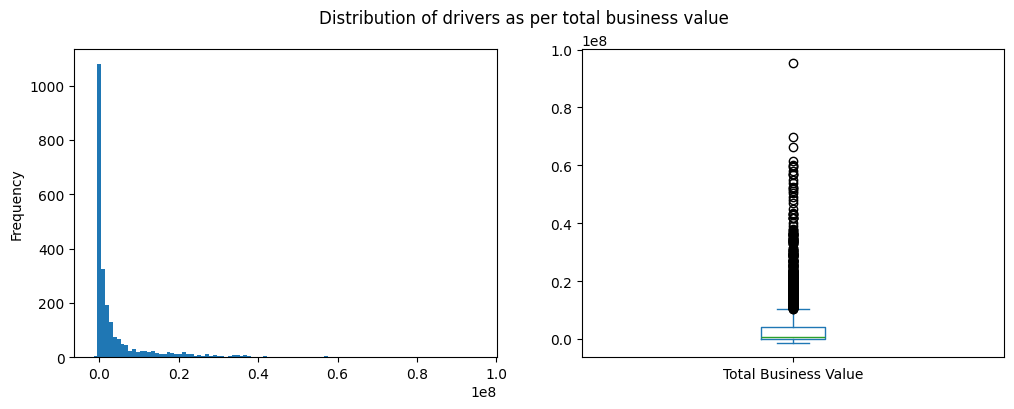

In [17]:
fig, axs = plt.subplots(1,2,figsize=(12,4))
temp_df = df.groupby('Driver_ID').agg({'Total Business Value':'sum'})['Total Business Value']
temp_df.plot(ax=axs[0], kind='hist', bins=100)
temp_df.plot(ax=axs[1], kind='box')
fig.suptitle('Distribution of drivers as per total business value')
plt.show()

### Insight
- It is very evident that **many drivers** have a **total business value of 0** and there are also a few drivers who have a -ve business value
- The distribution is extremely **right skewed**

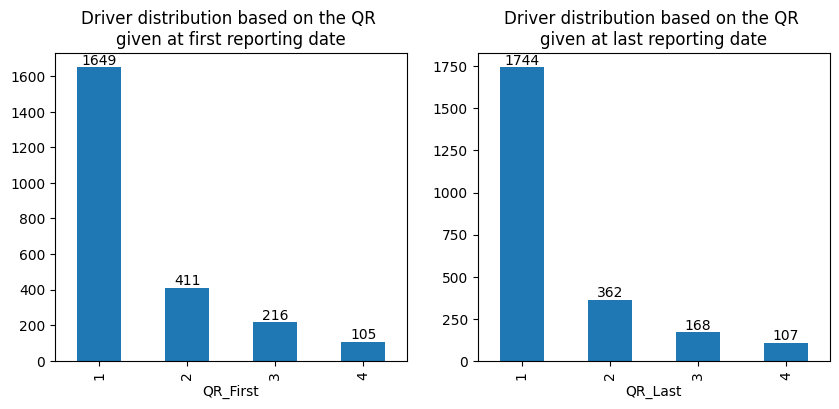

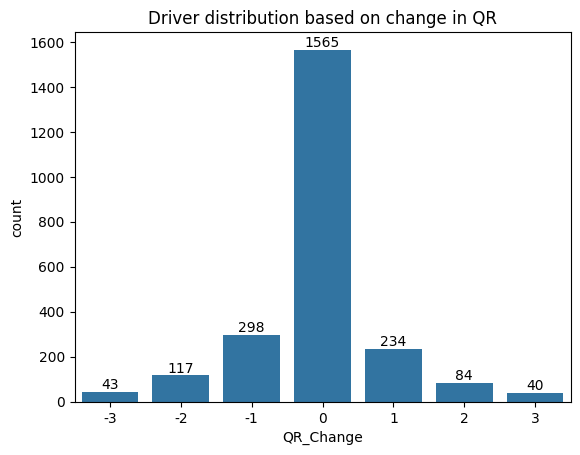

In [18]:
temp_df_1 = df.groupby('Driver_ID').agg({'Quarterly Rating':'first'}).reset_index()
temp_df_1.rename(columns = {'Quarterly Rating':'QR_First'}, inplace=True)
temp_df_2 = df.groupby('Driver_ID').agg({'Quarterly Rating':'last'}).reset_index()
temp_df_2.rename(columns = {'Quarterly Rating':'QR_Last'}, inplace=True)
temp_df = pd.merge(temp_df_1, temp_df_2, on='Driver_ID')
temp_df['QR_Change'] = temp_df['QR_Last'].astype('int') - temp_df['QR_First'].astype('int')
fig, axs = plt.subplots(1,2,figsize=(10,4))
ax = temp_df['QR_First'].value_counts().plot(kind='bar', ax=axs[0], title='Driver distribution based on the QR \ngiven at first reporting date')
ax.bar_label(ax.containers[0])
ax = temp_df['QR_Last'].value_counts().plot(kind='bar', ax=axs[1], title='Driver distribution based on the QR \ngiven at last reporting date')
ax.bar_label(ax.containers[0])
plt.show()
ax = sns.countplot(data=temp_df, x = 'QR_Change')
ax.set_title('Driver distribution based on change in QR')
ax.bar_label(ax.containers[0])
plt.show()

### Insight
- **Majority** of the drivers have a very **low quarterly rating of 1**
- The change in QR plot shows that **majority** of the drivers **don't see a change in their QR** but there are **decent number** of drivers with **positive change in QR** and equally decent number of drivers with **negative change in QR**
- There are **no drivers** with QR of **5**

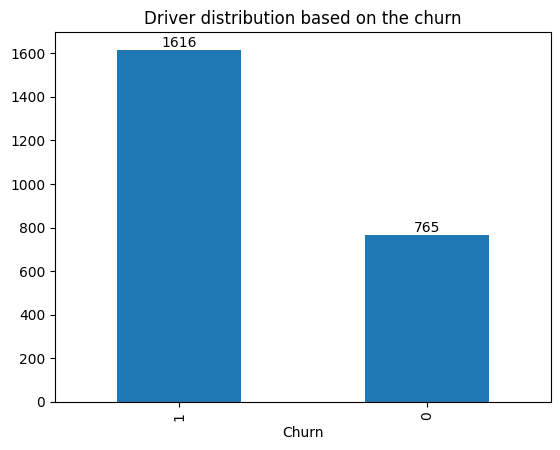

Churn
1    68.0
0    32.0
Name: proportion, dtype: float64

In [19]:
temp_df = df.groupby('Driver_ID').agg({'Churn':'first'})['Churn']
ax = temp_df.value_counts().plot(kind='bar', title='Driver distribution based on the churn')
ax.bar_label(ax.containers[0])
plt.show()
(temp_df.value_counts(normalize=True)*100).round(0)

## Bivariate analysis

In [20]:
df.Grade=df.Grade.astype('int')
driver_df = df.groupby('Driver_ID').agg({
    'ReportingMonthYear' : len,
    'Age' : 'last',
    'Gender' : 'first',
    'City' : 'first',
    'Education_Level' : 'first',
    'Income' : 'median',
    'Dateofjoining' : 'first',
    'LastWorkingDate' : 'last',
    'Joining Designation' : 'first',
    'Grade' : 'median',
    'Total Business Value' : 'sum',
    'Quarterly Rating' : 'median',
    'Churn':'last'
}).reset_index()
driver_df.rename(columns={'ReportingMonthYear': 'Months of Service'}, inplace=True)
driver_df.head(10)

,Driver_ID,Months of Service,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,Churn
0,1,3,28.0,Male,C23,Graduate,57387.0,2018-12-24,2019-11-03,1,1.0,1715580,2.0,1
1,2,2,31.0,Male,C7,Graduate,67016.0,2020-06-11,NaT,2,2.0,0,1.0,0
2,4,5,43.0,Male,C13,Graduate,65603.0,2019-07-12,2020-04-27,2,2.0,350000,1.0,1
3,5,3,29.0,Male,C9,10+,46368.0,2019-09-01,2019-07-03,1,1.0,120360,1.0,1
4,6,5,31.0,Female,C11,12+,78728.0,2020-07-31,NaT,3,3.0,1265000,2.0,0
5,8,3,34.0,Male,C2,10+,70656.0,2020-09-19,2020-11-15,3,3.0,0,1.0,1
6,11,1,28.0,Female,C19,Graduate,42172.0,2020-07-12,NaT,1,1.0,0,1.0,0
7,12,6,35.0,Male,C23,Graduate,28116.0,2019-06-29,2019-12-21,1,1.0,2607180,2.5,1
8,13,23,31.0,Male,C19,Graduate,119227.0,2015-05-28,2020-11-25,1,4.0,10213040,1.0,1
9,14,3,39.0,Female,C26,10+,19734.0,2020-10-16,NaT,3,3.0,0,1.0,0


In [21]:
drivers_with_2_year_service = driver_df[driver_df['Months of Service'] == 24]['Driver_ID'].reset_index(drop=True)

In [22]:
def calculate_change(df, column_name):
    temp_df_1 = df.groupby('Driver_ID').agg({column_name:'first'}).reset_index()
    first_column_name = column_name+'_First'
    temp_df_1.rename(columns = {column_name:first_column_name}, inplace=True)
    temp_df_2 = df.groupby('Driver_ID').agg({column_name:'last'}).reset_index()
    last_column_name = column_name+'_Last'
    temp_df_2.rename(columns = {column_name:last_column_name}, inplace=True)
    temp_df = pd.merge(temp_df_1, temp_df_2, on='Driver_ID')
    temp_df[column_name+'_Change'] = temp_df[last_column_name].astype('int') - temp_df[first_column_name].astype('int')
    temp_df.drop(columns=[first_column_name, last_column_name], inplace=True)
    return temp_df

In [23]:
column_name = 'Income'
temp_df1 = calculate_change(df, 'Income')
driver_df = pd.merge(driver_df, temp_df1, on='Driver_ID')
temp_df2 = calculate_change(df, 'Grade')
driver_df = pd.merge(driver_df, temp_df2, on='Driver_ID')
temp_df3 = calculate_change(df, 'Quarterly Rating')
driver_df = pd.merge(driver_df, temp_df3, on='Driver_ID')
driver_df['Quarterly Rating Improved'] = driver_df['Quarterly Rating_Change'].apply(lambda x: 1 if x>0 else 0)
driver_df.head()

,Driver_ID,Months of Service,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,Churn,Income_Change,Grade_Change,Quarterly Rating_Change,Quarterly Rating Improved
0,1,3,28.0,Male,C23,Graduate,57387.0,2018-12-24,2019-11-03,1,1.0,1715580,2.0,1,0,0,0,0
1,2,2,31.0,Male,C7,Graduate,67016.0,2020-06-11,NaT,2,2.0,0,1.0,0,0,0,0,0
2,4,5,43.0,Male,C13,Graduate,65603.0,2019-07-12,2020-04-27,2,2.0,350000,1.0,1,0,0,0,0
3,5,3,29.0,Male,C9,10+,46368.0,2019-09-01,2019-07-03,1,1.0,120360,1.0,1,0,0,0,0
4,6,5,31.0,Female,C11,12+,78728.0,2020-07-31,NaT,3,3.0,1265000,2.0,0,0,0,1,1


In [24]:
driver_df['Income_Raise'] = driver_df['Income_Change'].apply(lambda x: 1 if x>0 else 0)

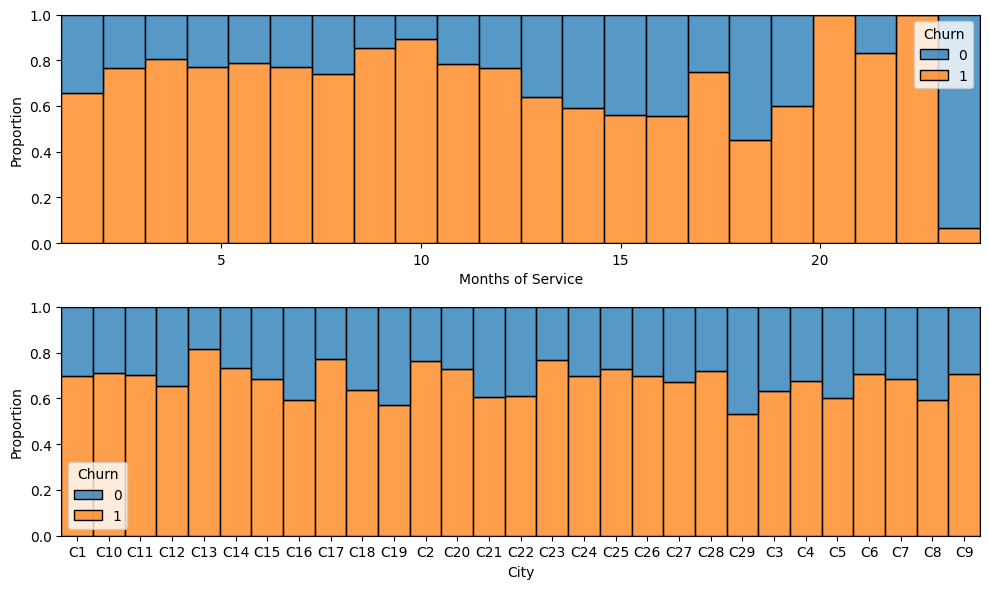

In [25]:
fig, axs = plt.subplots(2,1,figsize=(10,6))
sns.histplot(ax = axs[0], data=driver_df, x='Months of Service', hue='Churn', stat="proportion", multiple="fill")
sns.histplot(ax = axs[1], data=driver_df, x='City', hue='Churn', stat="proportion", multiple="fill")
plt.tight_layout()
plt.show()

### Insight
- The **churn** rate is generally **higher** in drivers with **less months of service** and low in drivers with longer months of service with exception for 21, 22 and 23 months of service where the churn rates seems to be very high
- The city **C13** has the **highest churn rate** and city **C29** has the **lowest churn rate**

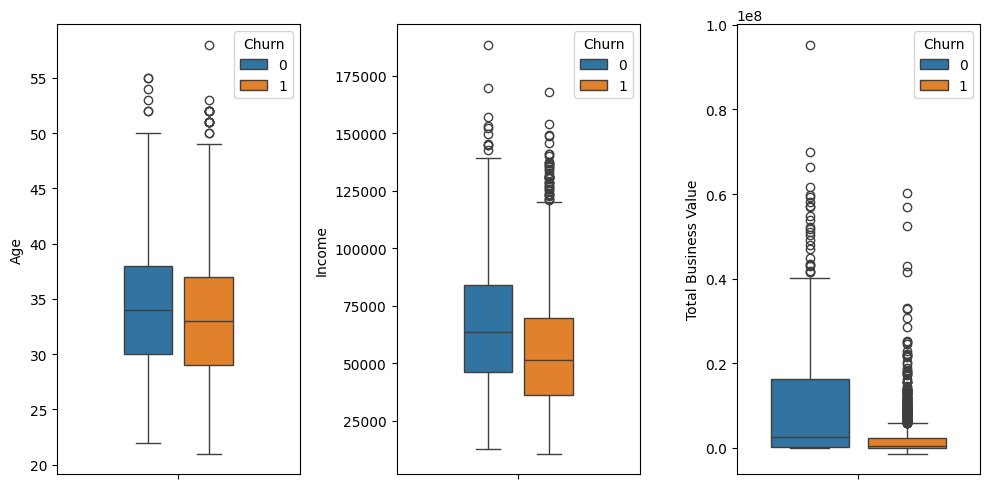

In [26]:
fig, axs = plt.subplots(1,3,figsize=(10,5))
sns.boxplot(ax=axs[0], data=driver_df, y='Age', hue='Churn', width=0.5, gap=0.2)
sns.boxplot(ax=axs[1], data=driver_df, y='Income', hue='Churn', width=0.5, gap=0.2)
sns.boxplot(ax=axs[2], data=driver_df, y='Total Business Value', hue='Churn', gap=0.2)
plt.tight_layout()
plt.show()

### Insight
- The **median age** of drivers who have **churned** is **slighly lesser** than that of the drivers who have not churned
- The **median income** of drivers who have **churned** is **lesser** than that of the drivers who have not churned
- The **median Total Bussiness Value** of drivers who have **churned** is **lesser** than that of the drivers who have not churned
- The drivers who have **churned** also had **-ve Total Bussiness Value**

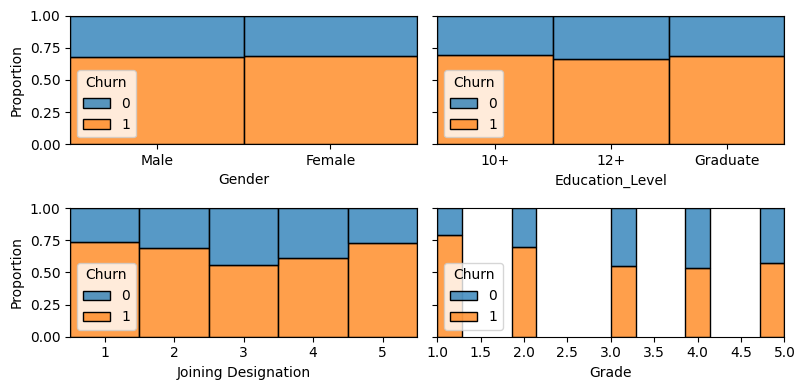

In [27]:
fig, axs = plt.subplots(2,2,figsize=(8,4),sharey=True)
sns.histplot(ax=axs[0,0], data=driver_df, x='Gender', hue='Churn', stat="proportion", multiple="fill")
sns.histplot(ax=axs[0,1], data=driver_df, x='Education_Level', hue='Churn', stat='proportion', multiple='fill')
sns.histplot(ax=axs[1,0], data=driver_df, x='Joining Designation', hue='Churn', stat='proportion', multiple='fill')
sns.histplot(ax=axs[1,1], data=driver_df, x='Grade', hue='Churn', stat='proportion', multiple='fill')
plt.tight_layout()
plt.show()

### Insight
- The **churn** rate is **almost equal** in both **male and female** drivers
- The **churn** rate is **almost equal** in **10+ and Graduates** and slighly **lower** in **12+**
- The **churn** rate is **less** for **joining designation 3**
- The **churn** rate is **less** for **higher grades**

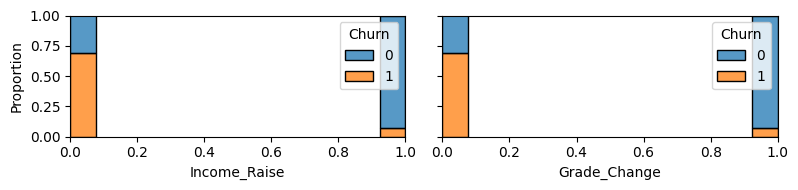

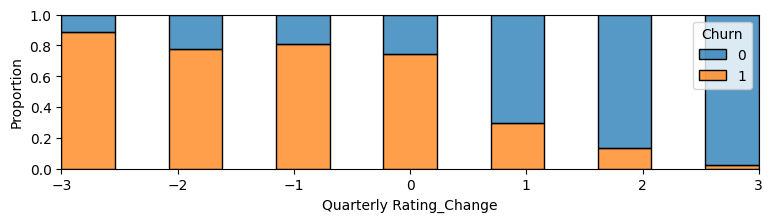

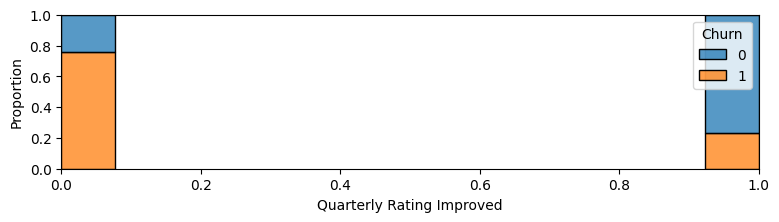

In [28]:
fig, axs = plt.subplots(1,2,figsize=(8,2),sharey=True)
sns.histplot(ax=axs[0], data=driver_df, x='Income_Raise', hue='Churn', stat='proportion', multiple='fill')
sns.histplot(ax=axs[1], data=driver_df, x='Grade_Change', hue='Churn', stat='proportion', multiple='fill')
plt.tight_layout()
plt.show()
plt.figure(figsize=(9,2))
sns.histplot(data=driver_df, x='Quarterly Rating_Change', hue='Churn', stat='proportion', multiple='fill')
plt.show()
plt.figure(figsize=(9,2))
sns.histplot(data=driver_df, x='Quarterly Rating Improved', hue='Churn', stat='proportion', multiple='fill')
plt.show()

### Insight
- The **churn rate** is **very less** in drivers whose **income has raised**
- The **churn rate** is **very less** in drivers whose **grade has raised**
- The **churn rate** is **very less** in drivers whose **Quarterly rating has increased**

/tmp/ipykernel_16057/2090613480.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_df = df.groupby(['City', 'ReportingYear']).agg({'Quarterly Rating': 'mean'}).reset_index()
/tmp/ipykernel_16057/2090613480.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  temp_df1 = pd.pivot_table(data=temp_df, index='City', columns='ReportingYear', values='Quarterly Rating').reset_index()


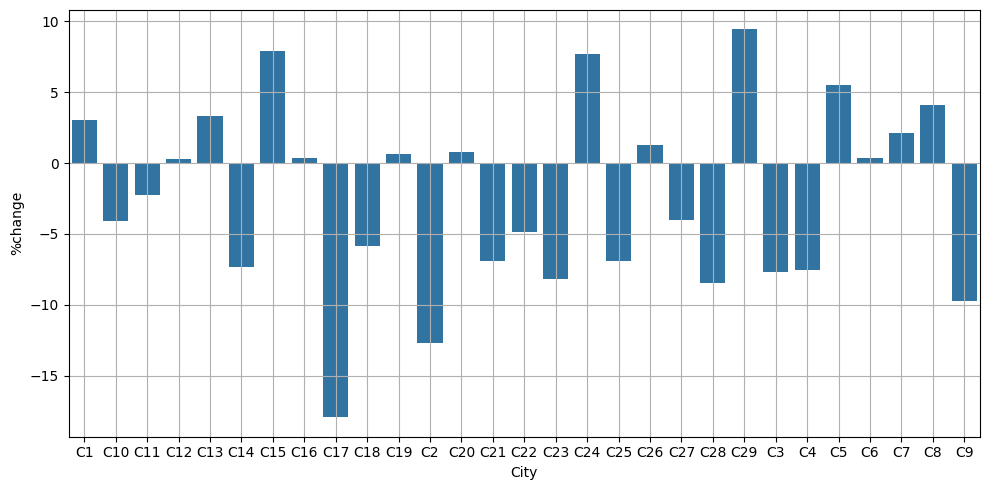

In [29]:
temp_df = df.groupby(['City', 'ReportingYear']).agg({'Quarterly Rating': 'mean'}).reset_index()
temp_df1 = pd.pivot_table(data=temp_df, index='City', columns='ReportingYear', values='Quarterly Rating').reset_index()
temp_df1.rename(columns={'ReportingYear':'index', 2019:'2019', 2020:'2020'}, inplace=True)
temp_df1['%change'] = (((temp_df1['2020'] - temp_df1['2019'])/temp_df1['2019'])*100).round(2)
plt.figure(figsize=(10,5))
sns.barplot(data=temp_df1, x='City', y='%change')
plt.tight_layout()
plt.grid(True)
plt.show()

### Insight
- The city **C29** shows  most improvement in Quarterly Rating in 2020 compared to 2019

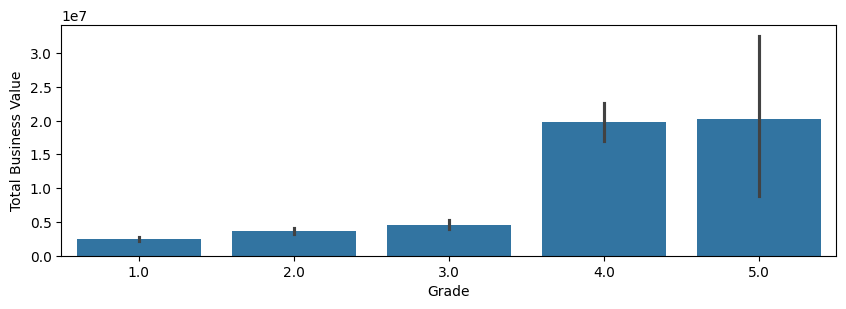

Mean of Total Business Value of drivers with grade 5: 424618700


In [30]:
plt.figure(figsize=(10,3))
sns.barplot(data=driver_df, x='Grade', y='Total Business Value', estimator='mean')
plt.show()
print('Mean of Total Business Value of drivers with grade 5:', driver_df[driver_df['Grade'] == 5]['Total Business Value'].sum())

### Insight
- The mean of Total Business Value of drivers with grade 5 is higher than those with other grades

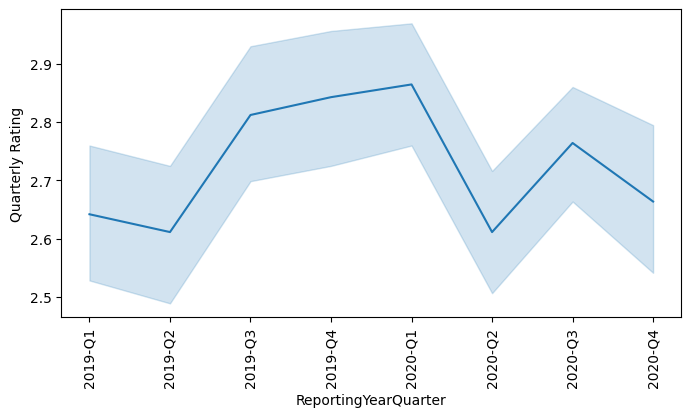

In [31]:
def convert_to_year_quarter(x):
    year = str(x.year)
    month = x.month
    if(month >=1 and month <=3):
        return year+'-Q1'
    elif(month >=4 and month <=6):
        return year+'-Q2'
    elif(month >=7 and month <=9):
        return year+'-Q3'
    else:
        return year+'-Q4'
    
temp_df = df.copy()
temp_df['ReportingYearQuarter']=temp_df['ReportingMonthYear'].apply(convert_to_year_quarter)
temp_df.head()
temp_driver_full_service_df = temp_df[temp_df['Driver_ID'].isin(drivers_with_2_year_service)].groupby(['Driver_ID', 'ReportingYearQuarter']).agg({'Quarterly Rating':'last', 'Total Business Value':'sum'}).reset_index()
plt.figure(figsize=(8,4))
sns.lineplot(data=temp_driver_full_service_df, x='ReportingYearQuarter', y='Quarterly Rating')
plt.xticks(rotation=90)
plt.show()

### Insight
- There is a dip in the quarterly rating in Q2 and then it increases in Q3.
- This pattern can be osberved for both the years

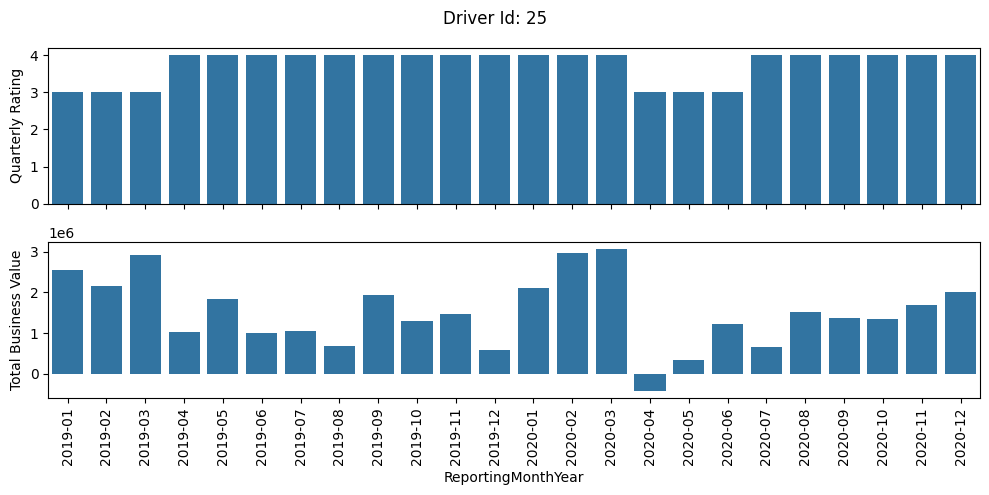

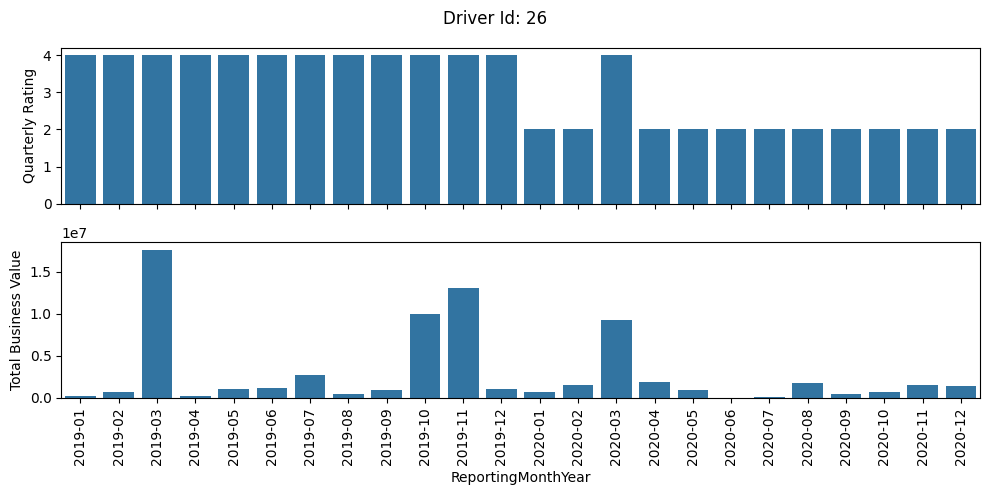

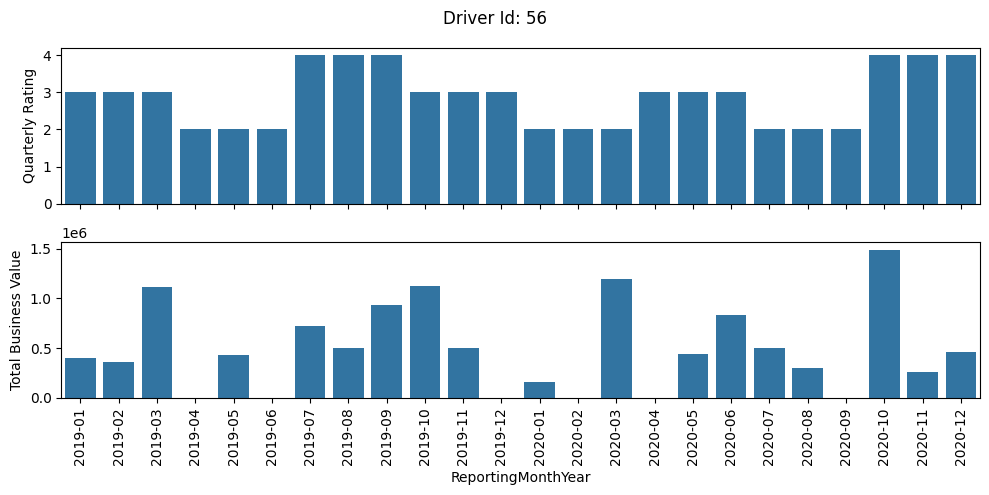

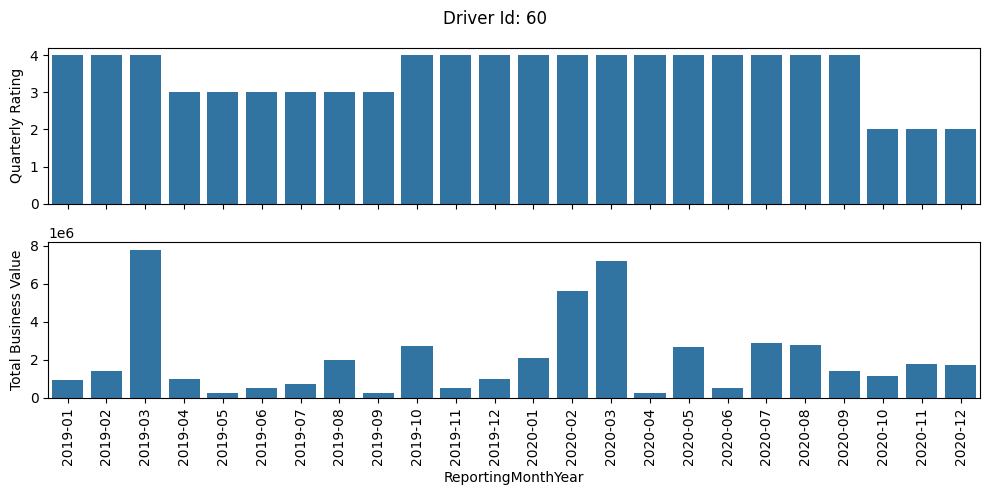

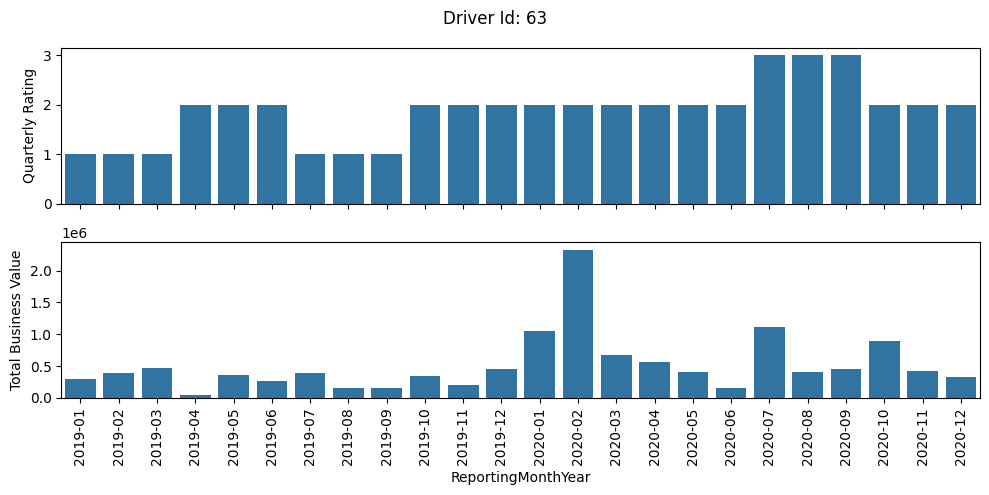

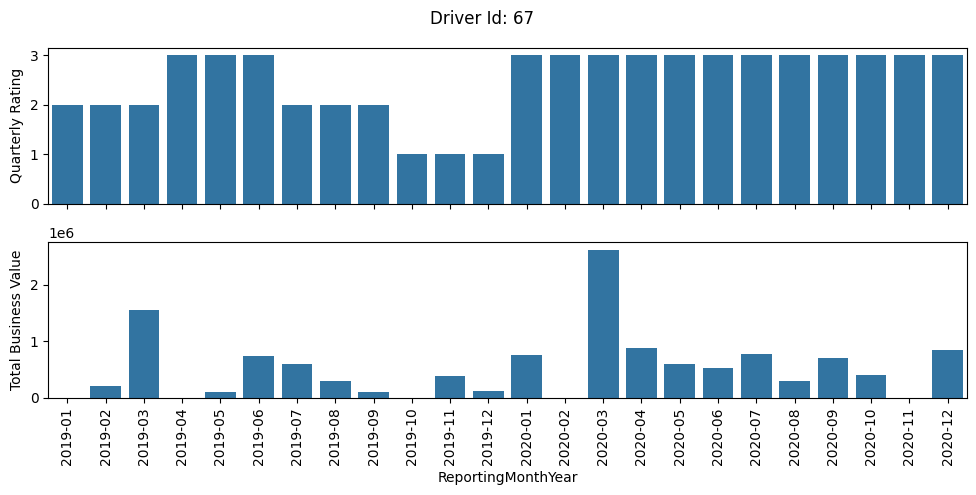

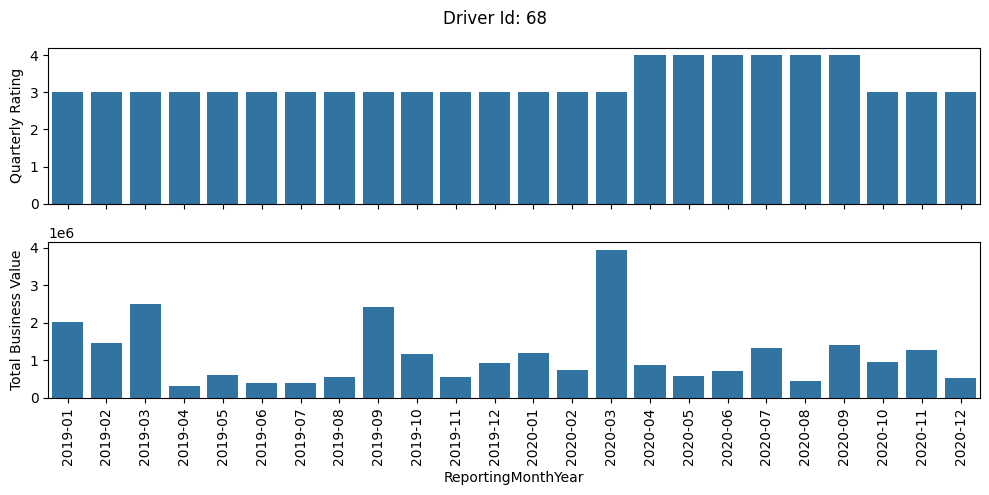

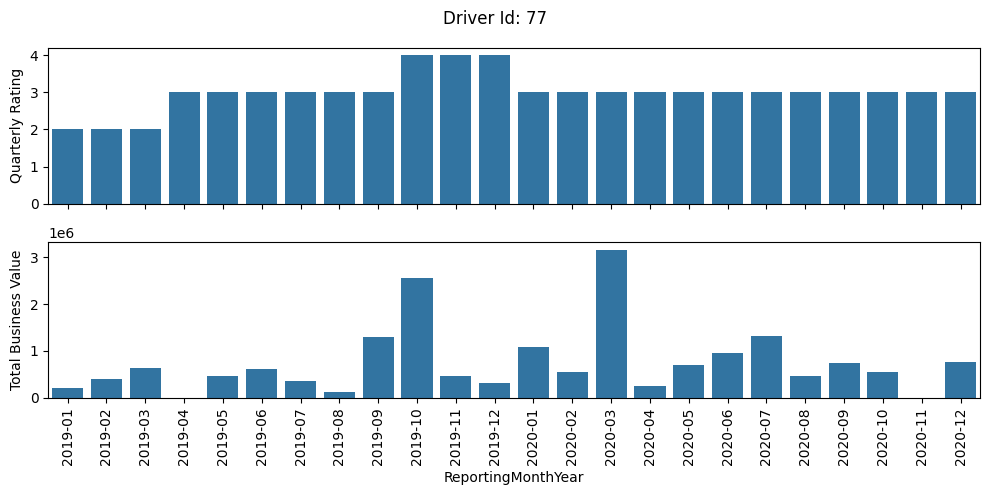

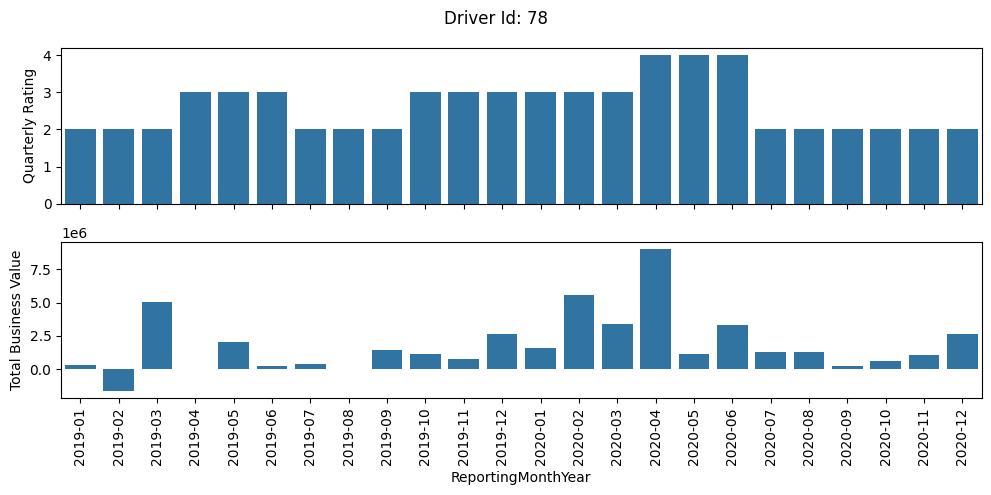

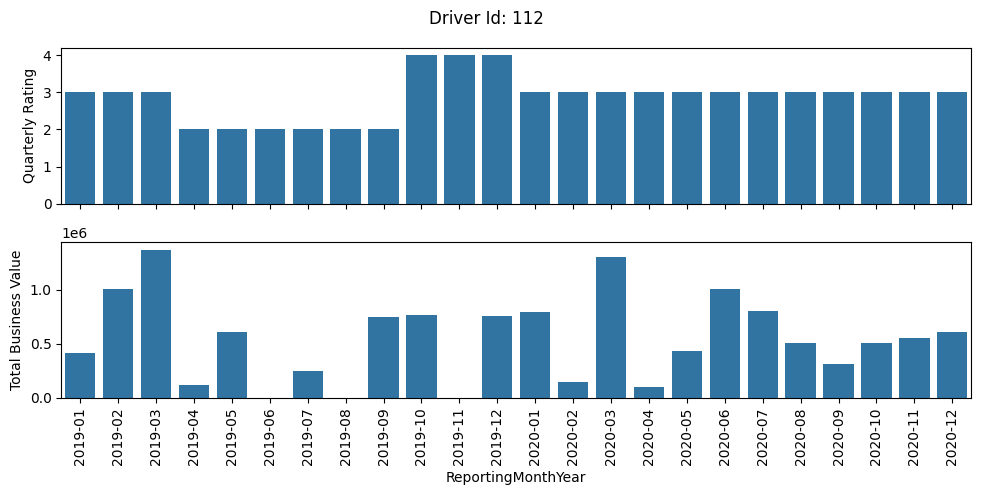

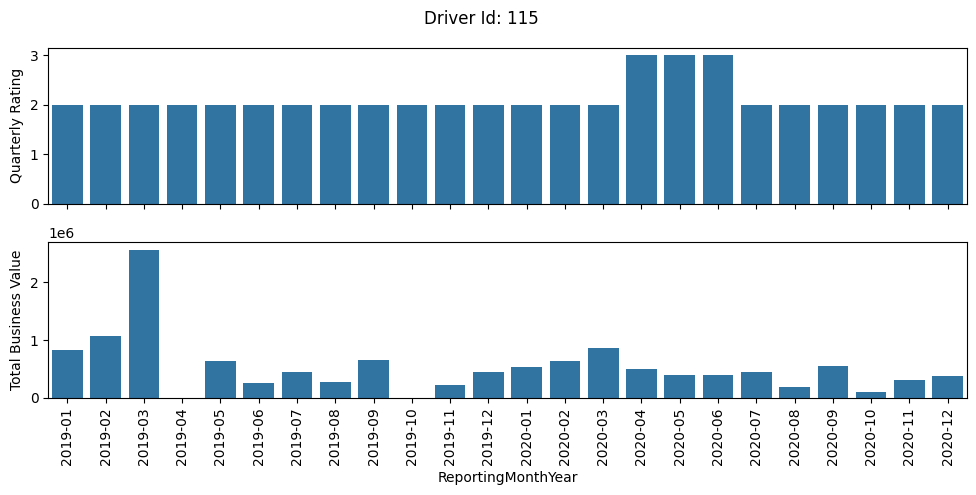

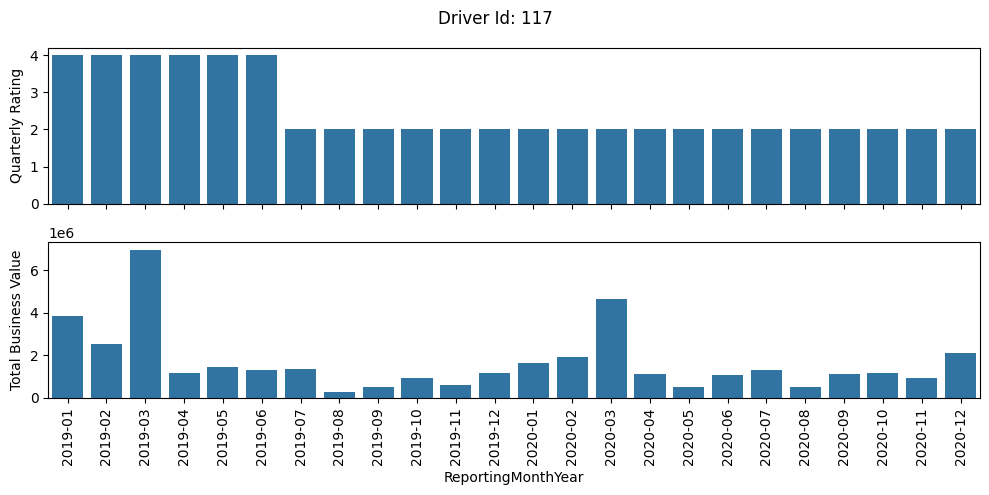

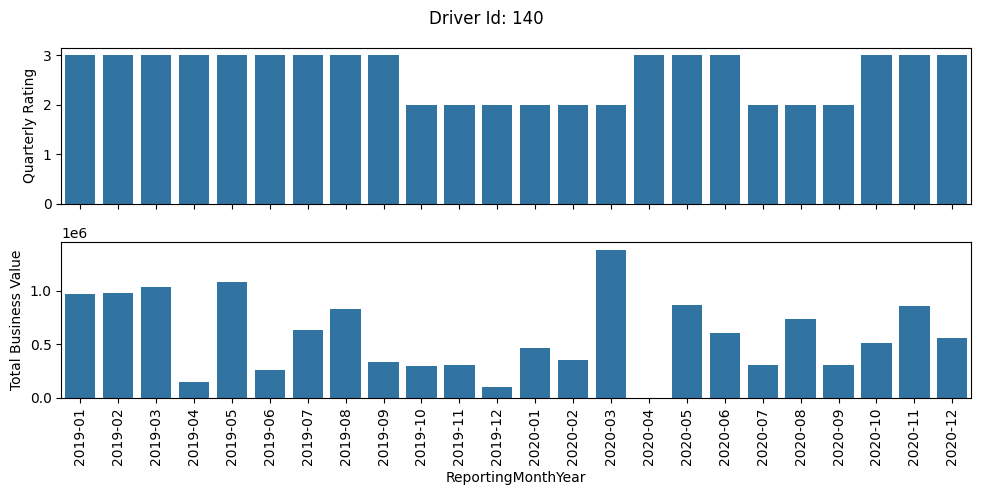

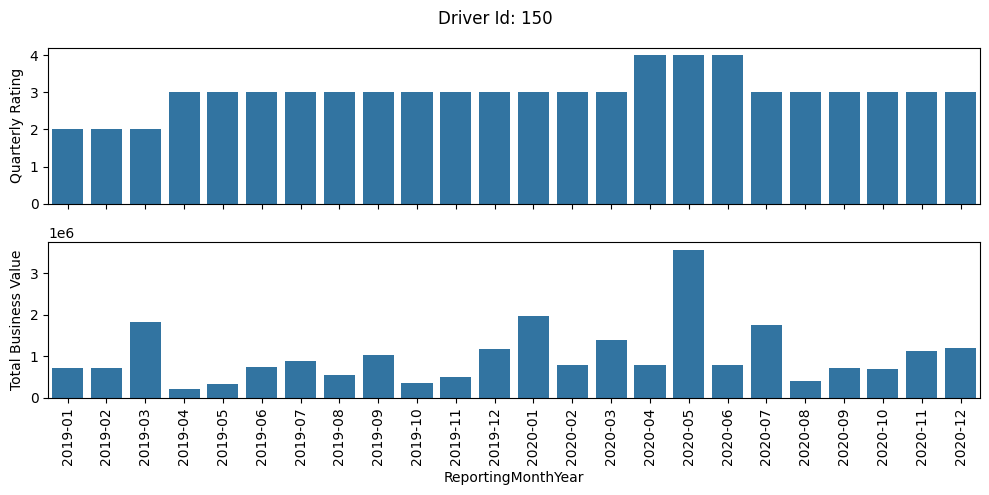

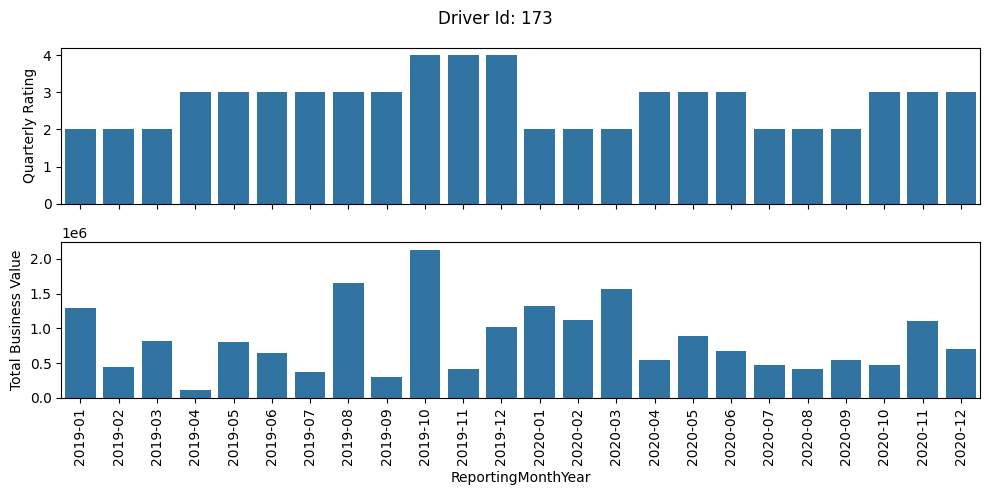

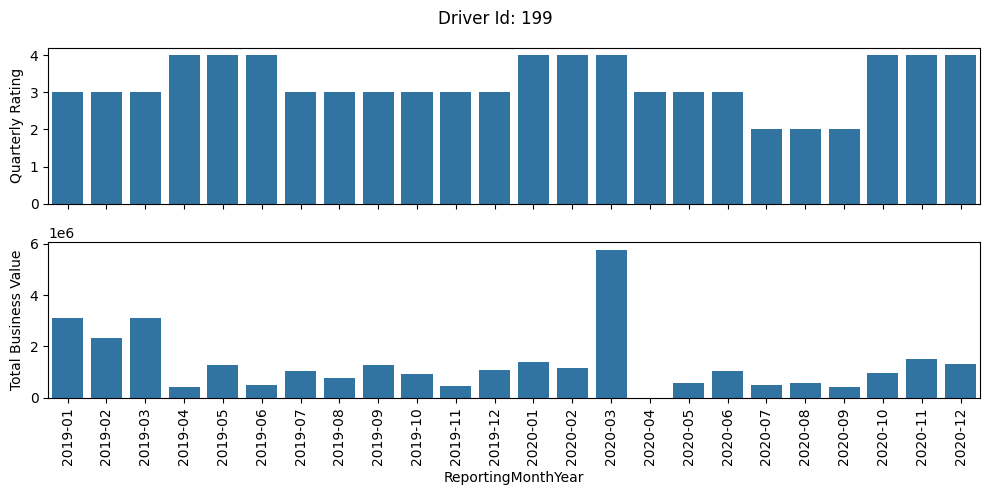

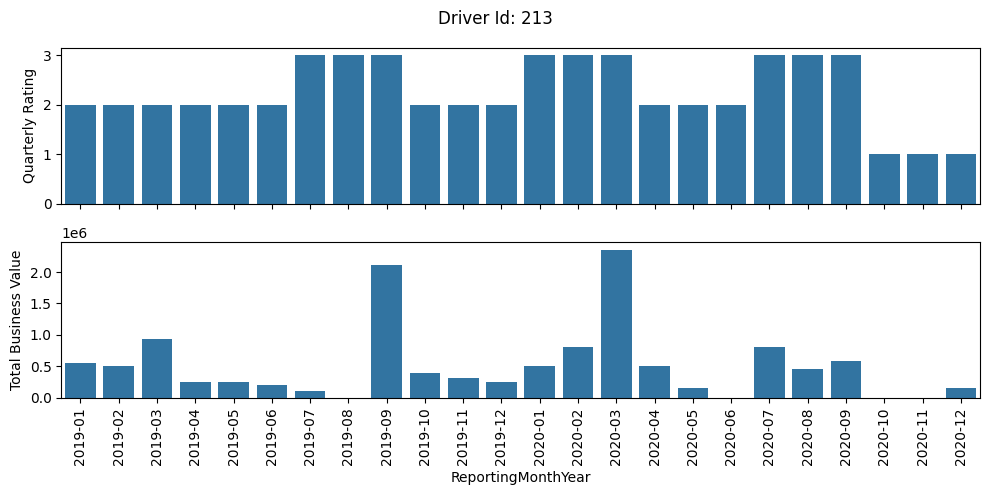

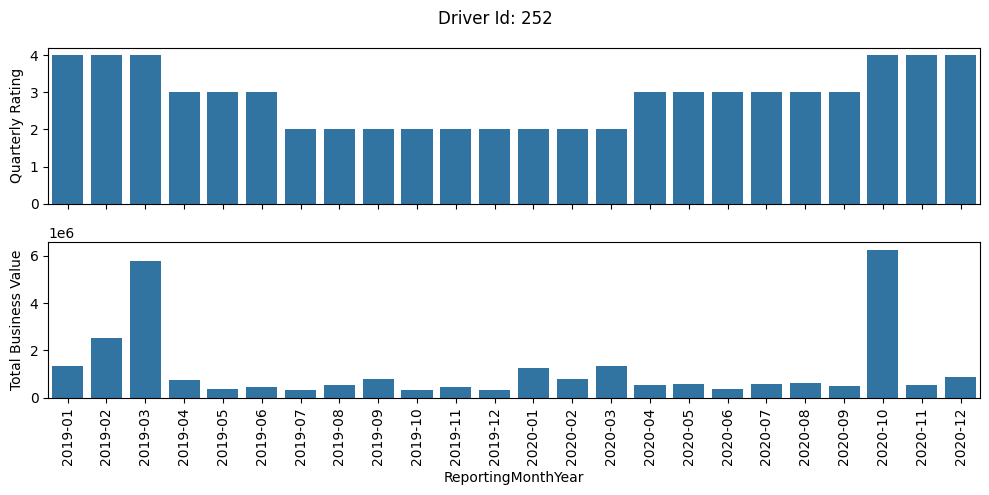

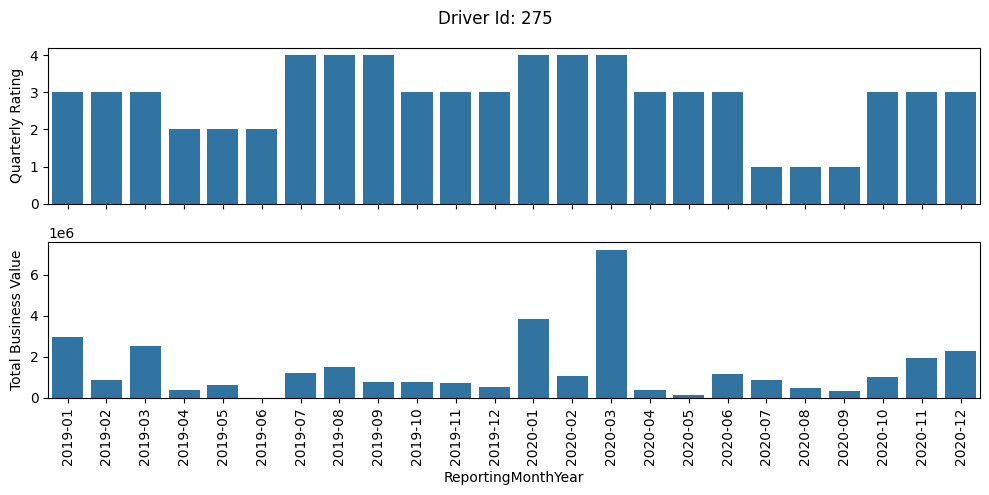

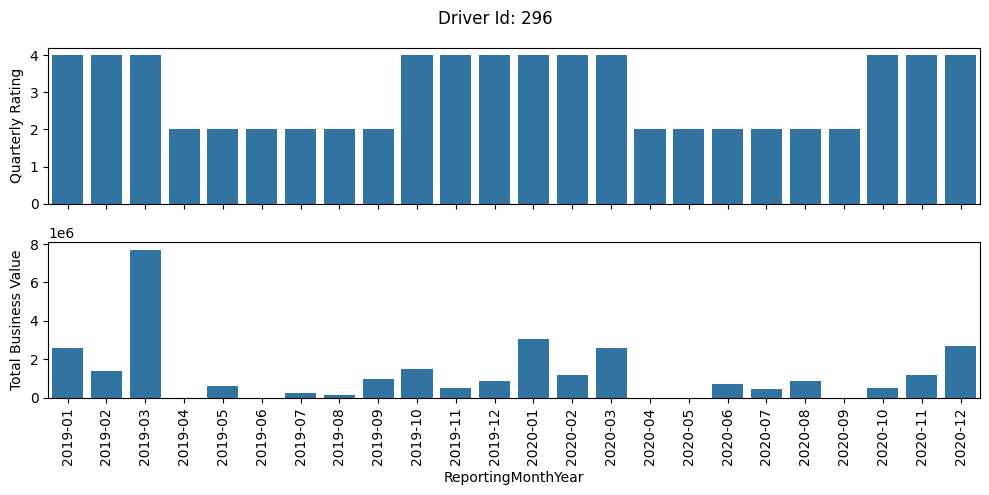

In [32]:
temp_driver_full_service_df = temp_df[temp_df['Driver_ID'].isin(drivers_with_2_year_service)]
num_of_drivers = 20
count=0
for driver_id in temp_driver_full_service_df['Driver_ID'].unique():
    if(count < num_of_drivers):
        count = count + 1
        sample_df = temp_driver_full_service_df[temp_driver_full_service_df['Driver_ID'] == driver_id]
        fig, axs = plt.subplots(2,1,figsize=(10, 5), sharex=True)
        sns.barplot(ax=axs[0], data=sample_df, x = 'ReportingMonthYear', y='Quarterly Rating')
        axs[0].tick_params(axis='x', rotation=90)
        sns.barplot(ax=axs[1], data=sample_df, x = 'ReportingMonthYear', y='Total Business Value')
        axs[1].tick_params(axis='x', rotation=90)
        fig.suptitle(f'Driver Id: {driver_id}')
        plt.tight_layout()
        plt.show()
    else:
        break

### Insight
- It can be observed that a significant drop in rating impacts the Total Business Value. Drop in rating demotivates the drivers, leading to accepting only a few rides or in somecases not accepting any rides and hence impacting the Total Business Value

## Multivariate analysis

In [33]:
driver_df['Gender'].replace({'Male':0, 'Female':1}, inplace=True)
driver_df['Education_Level'].replace({'Graduate':0, '10+':1, '12+':2}, inplace=True)
driver_df['City'] = driver_df['City'].str[1:]

/tmp/ipykernel_16057/2453968839.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  driver_df['Gender'].replace({'Male':0, 'Female':1}, inplace=True)
/tmp/ipykernel_16057/2453968839.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  driver_df['Gender'].replace({'Male':0, 'Female':1}, inplace=True)


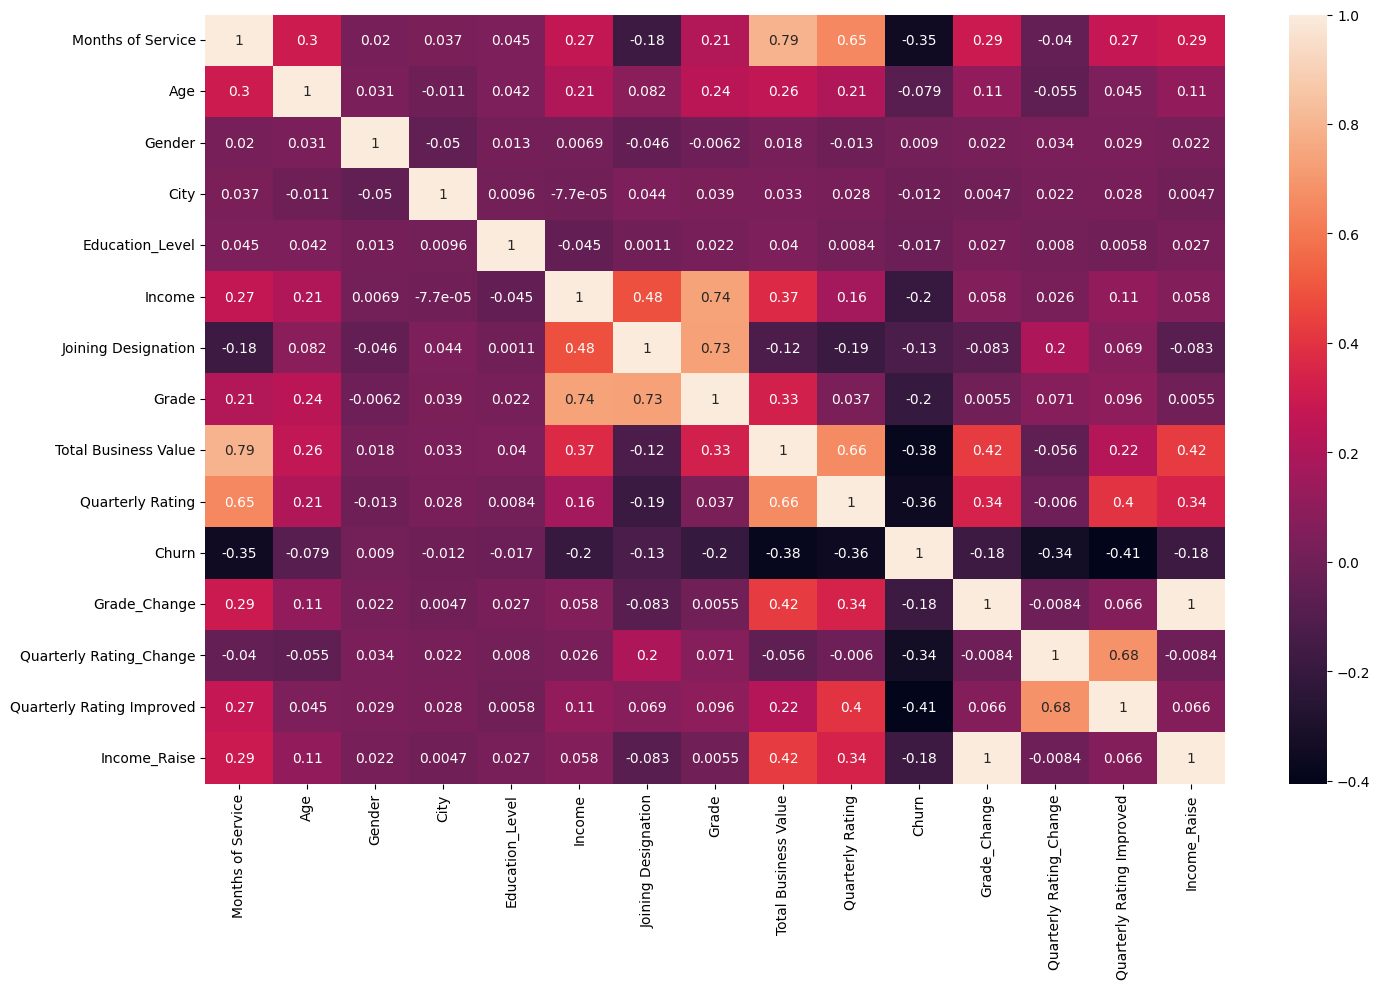

In [34]:
plt.figure(figsize=(15,10))
sns.heatmap(driver_df.drop(columns=['Driver_ID', 'Dateofjoining', 'LastWorkingDate', 'Income_Change']).corr(), annot=True)
plt.tight_layout()
plt.show()

### Insight
- **Months of Service** and **Total Business Value** are highly correlated
- **Income** and **Grade** are highly correlated
- **Joining Designation** and **Grade** are highly correlated
- **Quarterly Rating** and **Months of Service** are highly correlated
- **Chrun** is decently correlated with **Quarterly Rating, Total Business Value, Months of Service**

# Data Preprocessing

In [35]:
driver_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2381 entries, 0 to 2380
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Driver_ID                  2381 non-null   int64         
 1   Months of Service          2381 non-null   int64         
 2   Age                        2381 non-null   float64       
 3   Gender                     2381 non-null   category      
 4   City                       2381 non-null   object        
 5   Education_Level            2381 non-null   category      
 6   Income                     2381 non-null   float64       
 7   Dateofjoining              2381 non-null   datetime64[ns]
 8   LastWorkingDate            1616 non-null   datetime64[ns]
 9   Joining Designation        2381 non-null   category      
 10  Grade                      2381 non-null   float64       
 11  Total Business Value       2381 non-null   int64         
 12  Quarte

### Insight
- The columns **Driver_ID, Dateofjoining, LastWorkingDate** can be dropped as they do not contribute towards the driver churn rate

In [36]:
driver_df.drop(columns=['Driver_ID', 'Dateofjoining', 'LastWorkingDate'], inplace=True)
driver_df['Quarterly Rating'] = driver_df['Quarterly Rating'].astype('category')
driver_df['Churn'] = driver_df['Churn'].astype('category')
driver_df['Grade_Change'] = driver_df['Grade_Change'].astype('category')
driver_df['Quarterly Rating_Change'] = driver_df['Quarterly Rating_Change'].astype('category')
driver_df['Income_Raise'] = driver_df['Income_Raise'].astype('category')
driver_df.head()

,Months of Service,Age,Gender,City,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,Churn,Income_Change,Grade_Change,Quarterly Rating_Change,Quarterly Rating Improved,Income_Raise
0,3,28.0,0,23,0,57387.0,1,1.0,1715580,2.0,1,0,0,0,0,0
1,2,31.0,0,7,0,67016.0,2,2.0,0,1.0,0,0,0,0,0,0
2,5,43.0,0,13,0,65603.0,2,2.0,350000,1.0,1,0,0,0,0,0
3,3,29.0,0,9,1,46368.0,1,1.0,120360,1.0,1,0,0,0,0,0
4,5,31.0,1,11,2,78728.0,3,3.0,1265000,2.0,0,0,0,1,1,0


In [37]:
driver_df.duplicated().value_counts()

False    2381
Name: count, dtype: int64

### Insight
- There are no duplicates

## Handling null values

In [38]:
driver_df.isna().sum()

Months of Service            0
Age                          0
Gender                       0
City                         0
Education_Level              0
Income                       0
Joining Designation          0
Grade                        0
Total Business Value         0
Quarterly Rating             0
Churn                        0
Income_Change                0
Grade_Change                 0
Quarterly Rating_Change      0
Quarterly Rating Improved    0
Income_Raise                 0
dtype: int64

### Insight
- There are **no missing data or null values**

## Outlier Treatment

In [39]:
# helper function to detect outliers using IQR method
def detectOutliers_iqr(df):
    q1 = df.quantile(0.25)
    q3 = df.quantile(0.75)
    iqr = q3-q1
    lower_outliers = df[df<(q1-1.5*iqr)]
    higher_outliers = df[df>(q3+1.5*iqr)]
    return lower_outliers, higher_outliers

# helper function to detect outliers using standard deviation method
def detectOutliers_std(df):
    mean = df.mean()
    std = df.std()
    upper_limit = mean+(3*std)
    lower_limit = mean-(3*std)
    lower_outliers = df[df<lower_limit]
    higher_outliers = df[df>upper_limit]
    return lower_outliers, higher_outliers

In [40]:
numerical_columns = driver_df.select_dtypes(include=np.number).columns
column_outlier_dictionary = {}
for column in numerical_columns:
    lower_outliers, higher_outliers = detectOutliers_iqr(driver_df[column])
    column_outlier_dictionary[column] = [lower_outliers, higher_outliers]

In [41]:
for key, value in column_outlier_dictionary.items():
    print(f'The column \'{key}\' has {len(value[0]) + len(value[1])} outliers')

The column 'Months of Service' has 249 outliers
The column 'Age' has 25 outliers
The column 'Income' has 48 outliers
The column 'Grade' has 0 outliers
The column 'Total Business Value' has 336 outliers
The column 'Income_Change' has 43 outliers
The column 'Quarterly Rating Improved' has 358 outliers


In [42]:
numerical_columns = driver_df.select_dtypes(include=np.number).columns
column_outlier_dictionary = {}
for column in numerical_columns:
    lower_outliers, higher_outliers = detectOutliers_std(driver_df[column])
    column_outlier_dictionary[column] = [lower_outliers, higher_outliers]

In [43]:
for key, value in column_outlier_dictionary.items():
    print(f'The column \'{key}\' has {len(value[0]) + len(value[1])} outliers')

The column 'Months of Service' has 0 outliers
The column 'Age' has 14 outliers
The column 'Income' has 14 outliers
The column 'Grade' has 21 outliers
The column 'Total Business Value' has 64 outliers
The column 'Income_Change' has 43 outliers
The column 'Quarterly Rating Improved' has 0 outliers


### Insight
- I will **keep the outliers** in **Age** and **Income** columns as they are less in number
- I will **cap the outliers** in **Total Business Value** column as drivers with higher business value do not churn usually

In [44]:
mean = driver_df['Total Business Value'].mean()
std = driver_df['Total Business Value'].std()
upper_limit = mean+(3*std)
driver_df['Total Business Value'] = driver_df['Total Business Value'].apply(lambda x: x if x <= upper_limit else upper_limit)

## Multicollinearity Check

In [45]:
driver_df.Grade=driver_df.Grade.astype('category')
driver_df.City=driver_df.City.astype('category')

In [46]:
features_df = driver_df.drop(columns=['Churn']) # Drop target column
features_df = features_df.drop(columns=features_df.select_dtypes(include='category').columns)
#print(features_df.columns)
features_df = sm.add_constant(features_df)  # Adding a constant column for the intercept
vif_df = pd.DataFrame()
vif_df['Features'] = features_df.columns
vif_df['VIF'] = [variance_inflation_factor(features_df.values, idx) for idx in range(len(features_df.columns))]
vif_df['VIF'] = round(vif_df['VIF'], 2)
vif_df = vif_df.sort_values(by='VIF', ascending=False)
vif_df             

,Features,VIF
0,const,36.42
4,Total Business Value,4.53
1,Months of Service,3.92
5,Income_Change,1.24
3,Income,1.19
2,Age,1.13
6,Quarterly Rating Improved,1.09


## Insight
- Based on the above VIF scores, I can conclude that there are no multicolinear numerical features

## Encode categorical variables

In [47]:
df = driver_df.copy()

In [48]:
X = df.drop(columns=['Churn'])
y = df['Churn']
X.shape, y.shape

((2381, 15), (2381,))

In [49]:
y = y.astype(int)
X[['Grade_Change','Quarterly Rating_Change', 'Income_Raise']] = X[['Grade_Change','Quarterly Rating_Change', 'Income_Raise']].astype('int8')
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2381 entries, 0 to 2380
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Months of Service          2381 non-null   int64   
 1   Age                        2381 non-null   float64 
 2   Gender                     2381 non-null   category
 3   City                       2381 non-null   category
 4   Education_Level            2381 non-null   category
 5   Income                     2381 non-null   float64 
 6   Joining Designation        2381 non-null   category
 7   Grade                      2381 non-null   category
 8   Total Business Value       2381 non-null   float64 
 9   Quarterly Rating           2381 non-null   category
 10  Income_Change              2381 non-null   int64   
 11  Grade_Change               2381 non-null   int8    
 12  Quarterly Rating_Change    2381 non-null   int8    
 13  Quarterly Rating Improved  2381 n

In [50]:
categorical_columns = list(X.select_dtypes(include='category').columns)
categorical_columns

['Gender',
 'City',
 'Education_Level',
 'Joining Designation',
 'Grade',
 'Quarterly Rating']

In [51]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=95)

In [52]:
te = TargetEncoder()

X_train[categorical_columns] = te.fit_transform(X_train[categorical_columns], y_train)
X_test[categorical_columns] = te.transform(X_test[categorical_columns])

In [53]:
scaler=StandardScaler()
scols=['Months of Service','Income','Total Business Value']
X_train[scols]=scaler.fit_transform(X_train[scols])
X_test[scols]=scaler.transform(X_test[scols])

In [54]:
X_train.head()

,Months of Service,Age,Gender,City,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,Income_Change,Grade_Change,Quarterly Rating_Change,Quarterly Rating Improved,Income_Raise
1877,1.462948,29.0,0.684143,0.676505,0.681470,0.075354,0.734719,0.797980,0.382943,0.622685,0,0,-1,0,0
893,-0.451352,37.0,0.684143,0.748753,0.669841,1.164405,0.555556,0.550403,-0.430901,0.793750,0,0,0,0,0
640,-0.893113,27.0,0.678253,0.603576,0.690821,1.605130,0.555556,0.550403,-0.558843,0.793750,0,0,0,0,0
2199,-0.745859,28.0,0.678253,0.835067,0.669841,-0.336200,0.690184,0.699128,-0.558843,0.793750,0,0,0,0,0
1903,1.462948,26.0,0.684143,0.760587,0.669841,0.472533,0.734719,0.699128,1.151720,0.412714,0,0,-2,0,0


In [55]:
logreg = LogisticRegression(max_iter=100000)
logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)

f1_logreg = f1_score(y_test, y_pred_logreg)
print(f'Logistic Regression f1_score: {f1_logreg:.2f}')

Logistic Regression f1_score: 0.87


In [56]:
svm_model = SVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

f1_svm = accuracy_score(y_test, y_pred_svm)
print(f'SVM f1_score: {f1_svm:.2f}')

SVM f1_score: 0.68


In [57]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

f1_nb = accuracy_score(y_test, y_pred_nb)
print(f'Naive Bayes f1_score: {f1_nb:.2f}')

Naive Bayes f1_score: 0.80


In [58]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=95)

te = TargetEncoder()

X_train[categorical_columns] = te.fit_transform(X_train[categorical_columns], y_train)
X_test[categorical_columns] = te.transform(X_test[categorical_columns])

In [59]:
def rf_objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 1000, log=True)
    max_depth = trial.suggest_int("max_depth", 4, 128)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)

    model = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    random_state=95,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)

    return f1

study_Rf = optuna.create_study(study_name="Rf_Scaler",direction='maximize')  
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_Rf.optimize(rf_objective, n_trials=200, show_progress_bar=True)  
# Best parameters and score
print("Best Trial:")
print(f"  Value: {study_Rf.best_trial.value:.4f}")
print("  Params: ")
for key, value in study_Rf.best_trial.params.items():
    print(f"    {key}: {value}")


rf_final = RandomForestClassifier(**study_Rf.best_params,random_state=95)
rf_final.fit(X_train,y_train)
print(f1_score(y_test,rf_final.predict(X_test)))


[I 2025-01-15 19:03:18,490] A new study created in memory with name: Rf_Scaler
Best trial: 37. Best value: 0.908012: 100%|██████████| 200/200 [00:46<00:00,  4.31it/s]

Best Trial:
  Value: 0.9080
  Params: 
    n_estimators: 121
    max_depth: 66
    min_samples_split: 10
    min_samples_leaf: 1
0.9080118694362018


In [80]:
bestparamsrf={'n_estimators': 121, 'max_depth': 66, 'min_samples_split': 10, 'min_samples_leaf': 1}

                      Feature  Importance
0           Months of Service    0.208502
8        Total Business Value    0.187433
5                      Income    0.100142
13  Quarterly Rating Improved    0.099799
12    Quarterly Rating_Change    0.091515
3                        City    0.077940
1                         Age    0.068875
9            Quarterly Rating    0.048171
6         Joining Designation    0.043542
7                       Grade    0.029790
4             Education_Level    0.021538
2                      Gender    0.009531
11               Grade_Change    0.006267
14               Income_Raise    0.003595
10              Income_Change    0.003360


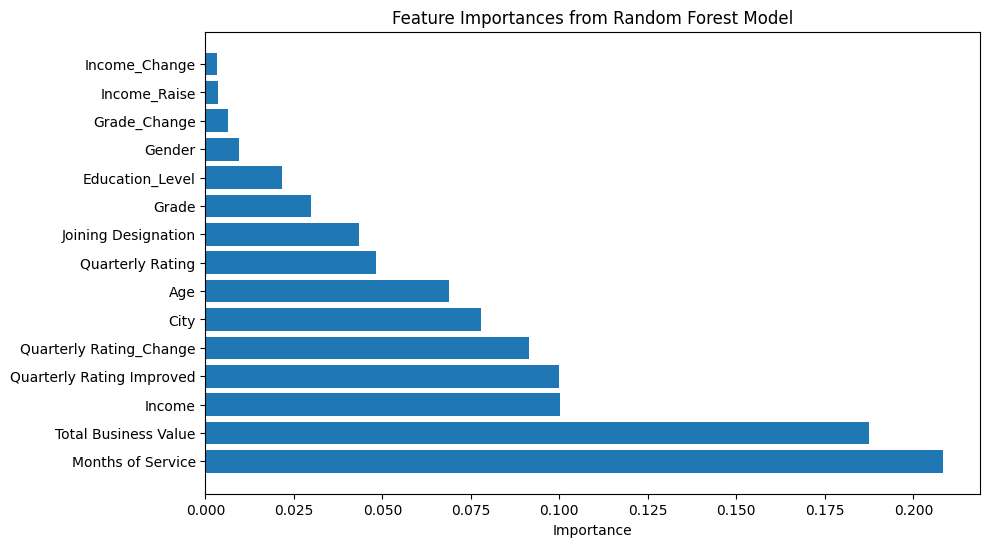

In [60]:
importances = rf_final.feature_importances_

feature_names = list(X.columns)
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)


plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importances from Random Forest Model')
plt.show()

In [61]:
#importance_evaluator = MeanDecreaseImpurityImportanceEvaluator()
#importances = importance_evaluator.evaluate(study_Rf)

#for feature_name, importance in importances.items():
    #print(f"Feature: {feature_name}, Importance: {importance}")

#fanova_evaluator = FanovaImportanceEvaluator()
#fanova_importances = fanova_evaluator.evaluate(study_Rf)

#for feature_name, importance in fanova_importances.items():
    #print(f"Feature: {feature_name}, Importance: {importance}")

In [62]:
def lgbm_objective(trial):

    lgbm_params = {
        "n_estimators": 2000,
        "subsample": trial.suggest_float("subsample", 0.3, 0.9),
        "min_child_samples": trial.suggest_int("min_child_samples", 60, 100),
        "max_depth": trial.suggest_int("max_depth", 4, 25),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.001, 0.1),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.001, 0.1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0)

    }

    lgbm_model = LGBMClassifier(**lgbm_params, random_state=95, verbose=-1)

    lgbm_model.fit(X_train, y_train)
    y_pred = lgbm_model.predict(X_test)
    return f1_score(y_test, y_pred)

study_LGBM = optuna.create_study(study_name="LGBM_Scaler", direction="maximize")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_LGBM.optimize(lgbm_objective, n_trials=200, show_progress_bar=True)

print("Best trial:", study_LGBM.best_trial)
print("Best parameters:", study_LGBM.best_params)

lgbm_final = LGBMClassifier(**study_LGBM.best_params,n_estimators= 2000,random_state=95,verbose=-1)
lgbm_final.fit(X_train, y_train)
y_pred = lgbm_final.predict(X_test)
print("f1:",f1_score(y_test, y_pred))

Best trial: 189. Best value: 0.899248: 100%|██████████| 200/200 [06:42<00:00,  2.01s/it]


Best trial: FrozenTrial(number=189, state=1, values=[0.8992481203007519], datetime_start=datetime.datetime(2025, 1, 15, 19, 10, 26, 836009), datetime_complete=datetime.datetime(2025, 1, 15, 19, 10, 28, 693316), params={'subsample': 0.6196351238133078, 'min_child_samples': 98, 'max_depth': 5, 'learning_rate': 0.01013533409032348, 'lambda_l1': 0.006033559440837454, 'lambda_l2': 0.03608558596290557, 'colsample_bytree': 0.35260320595633315}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'subsample': FloatDistribution(high=0.9, log=False, low=0.3, step=None), 'min_child_samples': IntDistribution(high=100, log=False, low=60, step=1), 'max_depth': IntDistribution(high=25, log=False, low=4, step=1), 'learning_rate': FloatDistribution(high=0.1, log=False, low=0.01, step=None), 'lambda_l1': FloatDistribution(high=0.1, log=False, low=0.001, step=None), 'lambda_l2': FloatDistribution(high=0.1, log=False, low=0.001, step=None), 'colsample_bytree': FloatDistribution(high=1.0

                      Feature  Importance
3                        City        4337
5                      Income        3598
1                         Age        2443
8        Total Business Value        1637
0           Months of Service        1616
7                       Grade        1310
9            Quarterly Rating         934
6         Joining Designation         676
4             Education_Level         611
12    Quarterly Rating_Change         579
2                      Gender         403
13  Quarterly Rating Improved         304
10              Income_Change           0
11               Grade_Change           0
14               Income_Raise           0


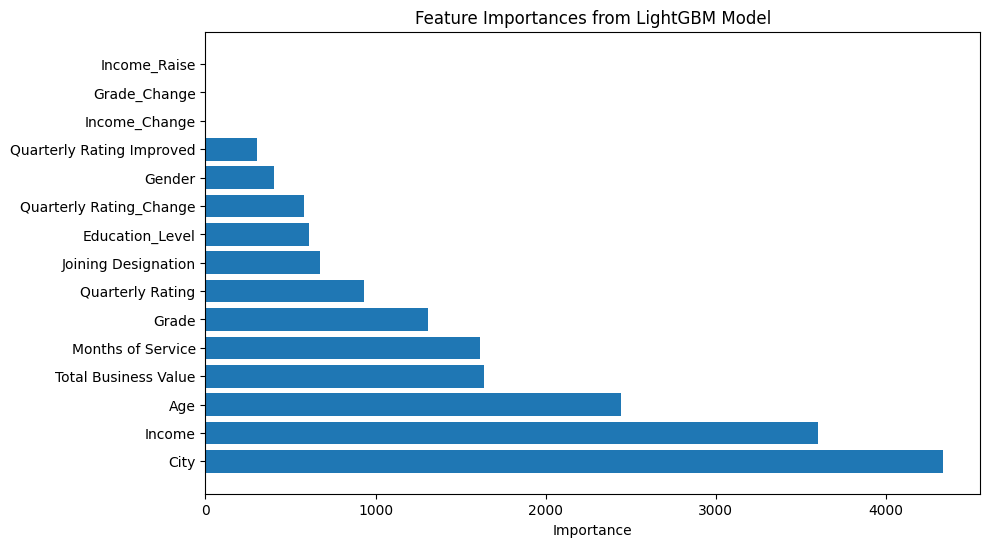

In [63]:
importances = lgbm_final.feature_importances_

feature_names = list(X.columns)
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)


plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importances from LightGBM Model')
plt.show()

In [64]:
def xgb_objective(trial):
    param = {
        'booster': trial.suggest_categorical('booster', ['gbtree', 'dart']),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_float('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
    }

    model = XGBClassifier(**param, random_state=95)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds)
    return f1


study_XGB = optuna.create_study(study_name='XGB_Scaler',direction='maximize')  
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_XGB.optimize(xgb_objective, n_trials=200, show_progress_bar=True)  

# Best parameters and score
print("Best Trial:")
print(f"  Value: {study_XGB.best_trial.value:.4f}")
print("  Params: ")
for key, value in study_XGB.best_trial.params.items():
    print(f"    {key}: {value}")

xgb_final = XGBClassifier(**study_XGB.best_params,random_state=95,verbose=-1)
xgb_final.fit(X_train,y_train)
print(f1_score(y_test,xgb_final.predict(X_test)))

Best trial: 93. Best value: 0.90313: 100%|██████████| 200/200 [03:26<00:00,  1.03s/it]
/home/diptyajitdas/.local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [19:14:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "verbose" } are not used.

  warnings.warn(smsg, UserWarning)


Best Trial:
  Value: 0.9031
  Params: 
    booster: gbtree
    learning_rate: 0.07570340822895463
    n_estimators: 75
    max_depth: 5
    min_child_weight: 1.1843987977941361
    gamma: 1.2808224699422666
    subsample: 0.7668248173714789
    colsample_bytree: 0.9543711480063714
    lambda: 0.0023948156665294083
    alpha: 4.419396841322494
0.9031296572280179


                      Feature  Importance
12    Quarterly Rating_Change    0.220122
0           Months of Service    0.197306
8        Total Business Value    0.150643
6         Joining Designation    0.132505
13  Quarterly Rating Improved    0.063187
9            Quarterly Rating    0.057297
7                       Grade    0.042921
3                        City    0.038370
1                         Age    0.037828
5                      Income    0.031032
4             Education_Level    0.028789
2                      Gender    0.000000
10              Income_Change    0.000000
11               Grade_Change    0.000000
14               Income_Raise    0.000000


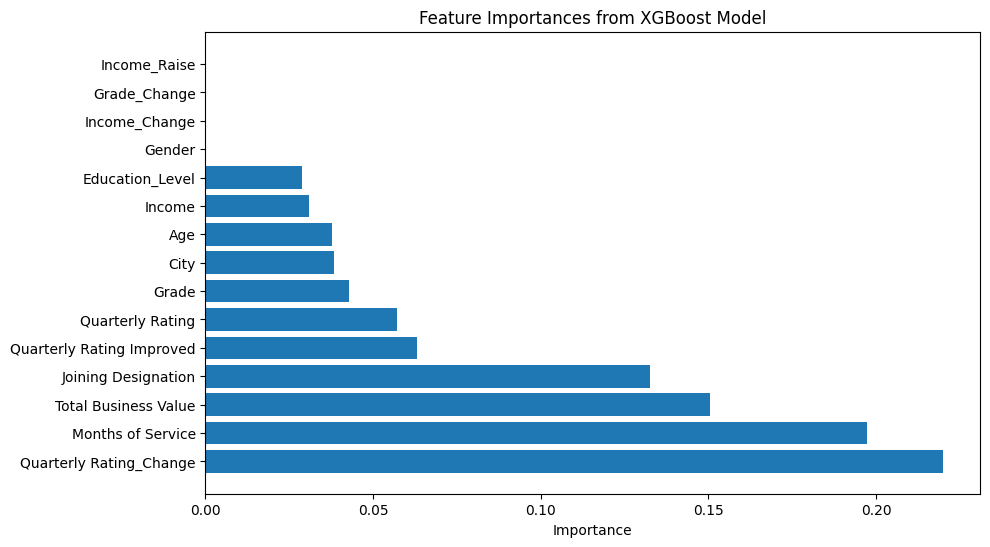

In [65]:
importances = xgb_final.feature_importances_

feature_names = list(X.columns)
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)


plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importances from XGBoost Model')
plt.show()

In [66]:
rf_weight=f1_score(y_test,rf_final.predict(X_test))
xgb_weight=f1_score(y_test,xgb_final.predict(X_test))
lightgbm_weight=f1_score(y_test,lgbm_final.predict(X_test))

voting_clf = VotingClassifier(estimators=[
    #('logreg', logreg),
    #('svm', svm_model),
    #('nb', nb_model),
    ('rf', rf_final),
    ('xgb', xgb_final),
    ('lgbm', lgbm_final)
], voting='soft',weights=[rf_weight,xgb_weight,lightgbm_weight])

voting_clf.fit(X_train, y_train)

y_pred = voting_clf.predict(X_test)
f1 = f1_score(y_test, y_pred)

print(f'F1 Score: {f1}')

/home/diptyajitdas/.local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [19:14:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "verbose" } are not used.

  warnings.warn(smsg, UserWarning)


F1 Score: 0.9001490312965723


In [67]:
color = '\033[91m'
bold = '\033[1m'
end = '\033[0m'
# Predict and evaluate performance
y_true = y_train
y_pred = voting_clf.predict(X_train)
print(color + bold + "Train data:" + color + end)
print("f1_score: ", f1_score(y_true, y_pred))
print("Classification Report:\n", classification_report(y_true, y_pred))
y_true = y_test
y_pred = voting_clf.predict(X_test)
print(color + bold + "Test data:" + color + end)
print("f1_score: ", f1_score(y_true, y_pred))
print("Classification Report:\n", classification_report(y_true, y_pred))

Train data:
f1_score:  0.9139509337239107
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.69      0.78       608
           1       0.87      0.96      0.91      1296

    accuracy                           0.88      1904
   macro avg       0.88      0.83      0.85      1904
weighted avg       0.88      0.88      0.87      1904

Test data:
f1_score:  0.9001490312965723
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.69      0.76       157
           1       0.86      0.94      0.90       320

    accuracy                           0.86       477
   macro avg       0.86      0.82      0.83       477
weighted avg       0.86      0.86      0.86       477



In [68]:
model=xgb_final
model_type='XGBoost'
if rf_weight>xgb_weight:
    model=rf_final
    model_type='Random Forest'

In [69]:
color = '\033[91m'
bold = '\033[1m'
end = '\033[0m'
# Predict and evaluate performance
y_true = y_train
y_pred = model.predict(X_train)
print(color + bold + "Train data:" + color + end)
print("f1_score: ", f1_score(y_true, y_pred))
print("Classification Report:\n", classification_report(y_true, y_pred))
y_true = y_test
y_pred = model.predict(X_test)
print(color + bold + "Test data:" + color + end)
print("f1_score: ", f1_score(y_true, y_pred))
print("Classification Report:\n", classification_report(y_true, y_pred))

Train data:
f1_score:  0.9403482771396814
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.78      0.85       608
           1       0.90      0.98      0.94      1296

    accuracy                           0.92      1904
   macro avg       0.93      0.88      0.90      1904
weighted avg       0.92      0.92      0.91      1904

Test data:
f1_score:  0.9080118694362018
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.69      0.78       157
           1       0.86      0.96      0.91       320

    accuracy                           0.87       477
   macro avg       0.88      0.83      0.84       477
weighted avg       0.87      0.87      0.87       477



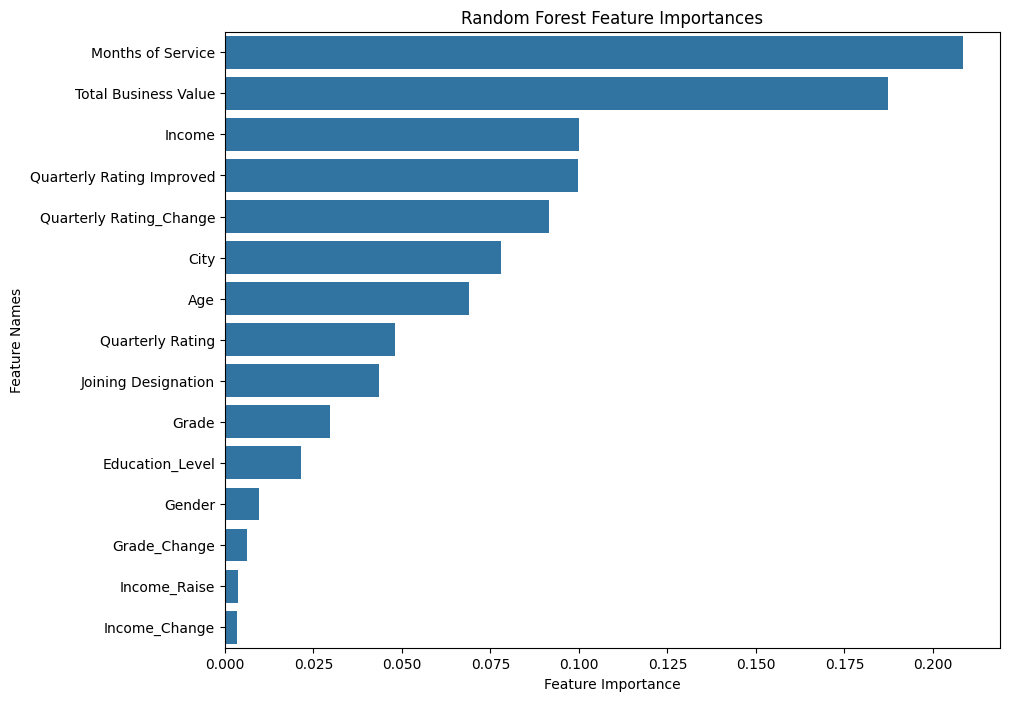

In [75]:
def plot_feature_importance(importance,names,model_type):
    feature_importance = np.array(importance)
    feature_names = np.array(names)

    data={'feature_names':feature_names,'feature_importance':feature_importance}
    fi_df = pd.DataFrame(data)

    fi_df.sort_values(by=['feature_importance'], ascending=False,inplace=True)

    plt.figure(figsize=(10,8))
    sns.barplot(x=fi_df['feature_importance'], y=fi_df['feature_names'])
    plt.title(model_type + ' Feature Importances')
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature Names')
    plt.show()

plot_feature_importance(model.feature_importances_,X_train.columns,model_type)

In [71]:
#xgb.plot_importance(xgb_final, )
#plt.show()

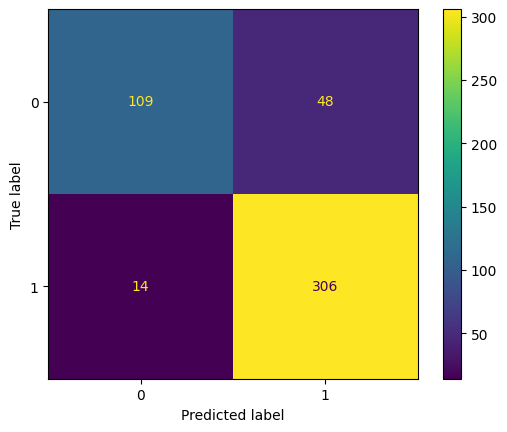

In [76]:
disp=ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred,labels=model.classes_))
disp.plot()
plt.show()

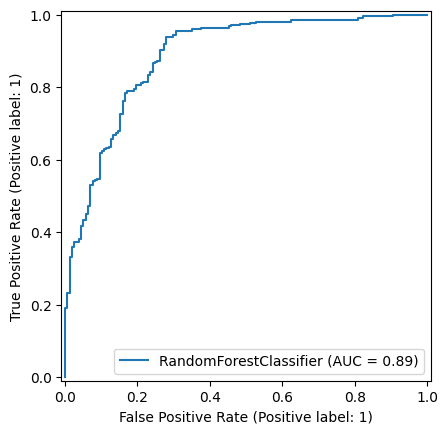

In [77]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

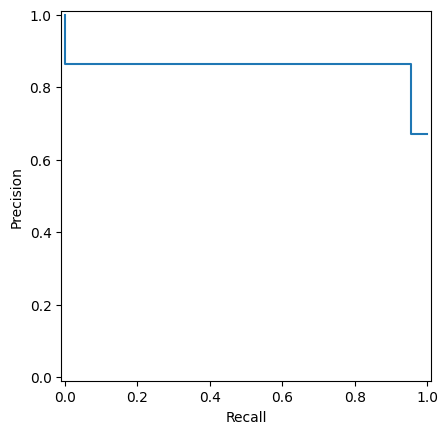

In [78]:
precision, recall, _ = precision_recall_curve(y_test, model.predict(X_test))
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()
plt.show()

In [1]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
y_train_pred = model.predict(X)  

plt.figure(figsize=(10, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_pred, edgecolors='k', marker='o', alpha=0.7)

plt.title('Decision Boundary Visualization with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

NameError: name 'X' is not defined